In [5]:
conda install -c conda-forge scikit-learn

Jupyter detected...
3 channel Terms of Service accepted
Retrieving notices: done
Channels:
 - conda-forge
 - defaults
Platform: win-64
Solving environment: done

## Package Plan ##

  environment location: C:\Users\juanb\miniconda3

  added / updated specs:
    - scikit-learn


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    ca-certificates-2026.7.22  |       h4c7d964_0         129 KB  conda-forge
    certifi-2026.7.22          |     pyhd8ed1ab_0         134 KB  conda-forge
    cloudpickle-3.1.2          |     pyhcf101f3_1          27 KB  conda-forge
    joblib-1.6.0               |     pyhcf101f3_0         223 KB  conda-forge
    openssl-3.6.4              |       hf411b9b_0         9.0 MB  conda-forge
    scikit-learn-1.9.1         |np2py313h4ce4a18_0         8.8 MB  conda-forge
    scipy-1.18.1               |  py313h97a0a95_0        20.8 MB
    threadpoolctl-3.6.0        |     pyheca



==> WARNING: A newer version of conda exists. <==
    current version: 26.3.2
    latest version: 26.7.2

Please update conda by running

    $ conda update -n base -c conda-forge conda




Rows: 36,807 | Unparsed dates: 0


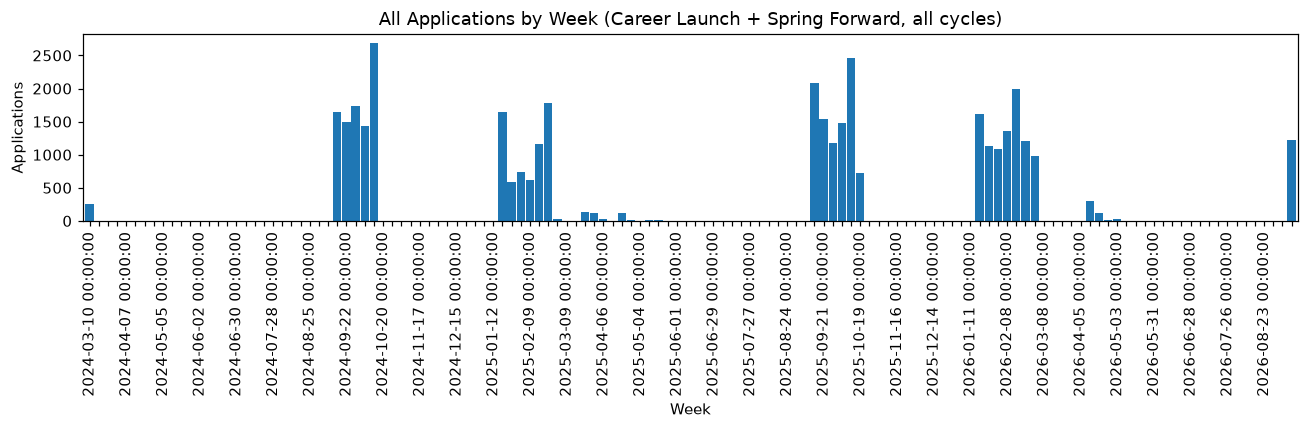

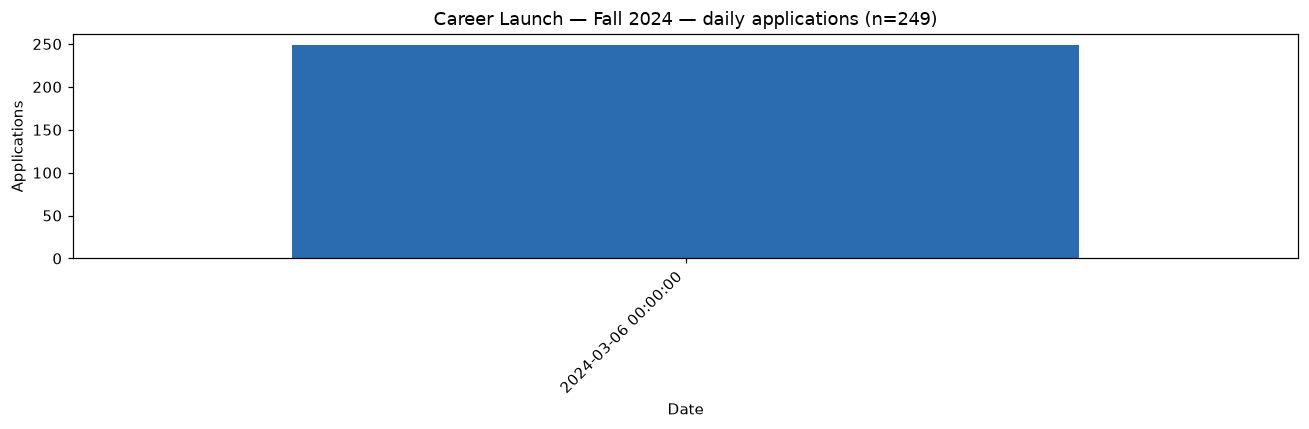

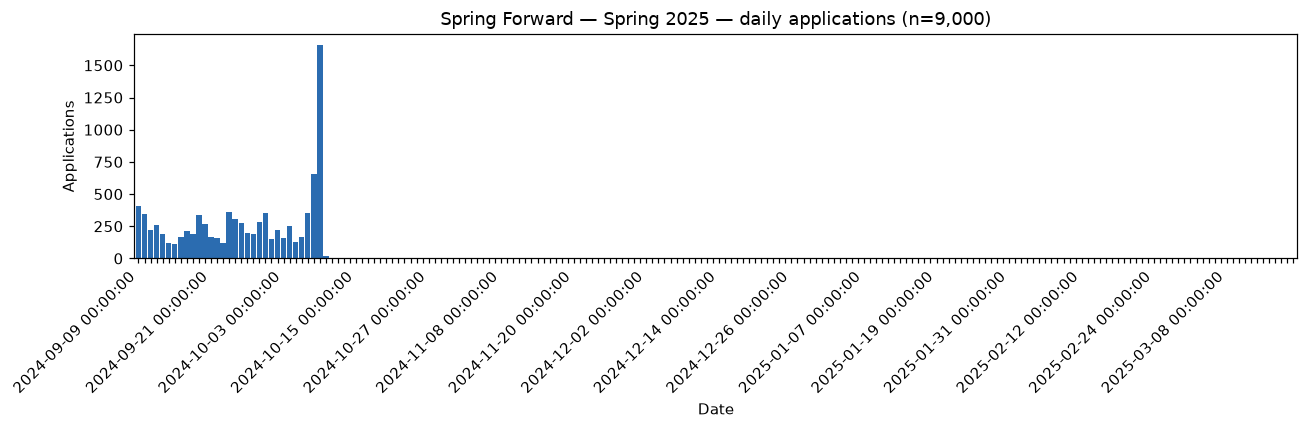

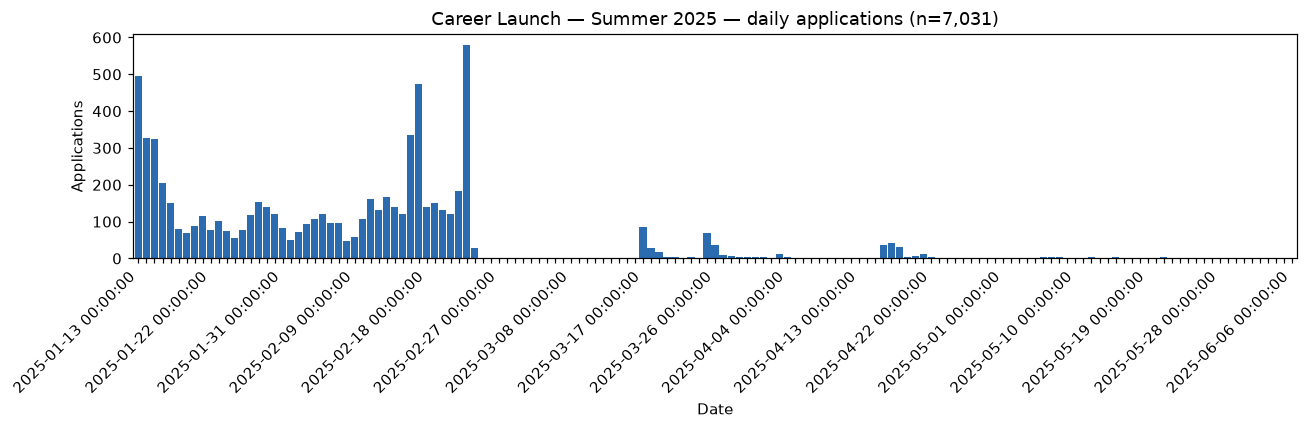

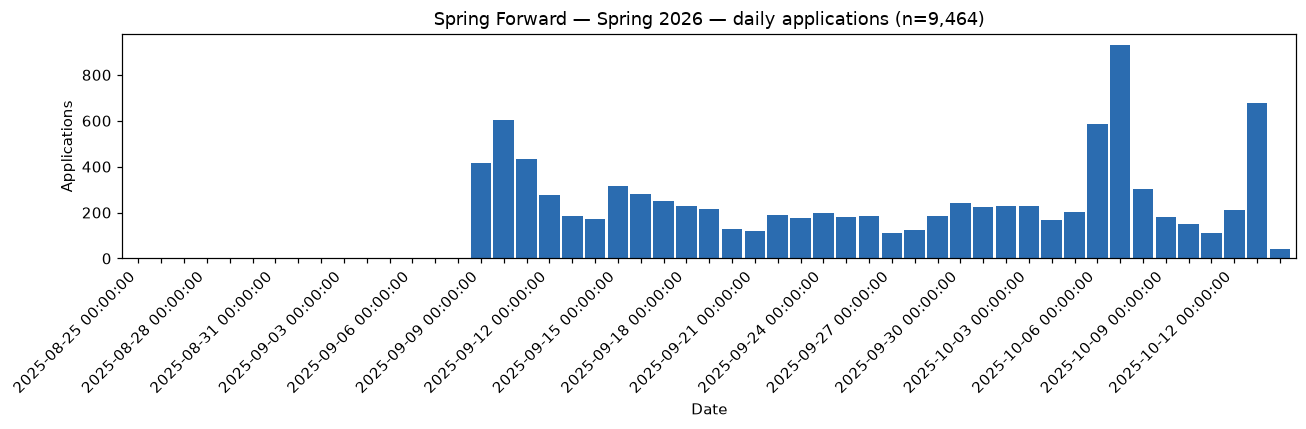

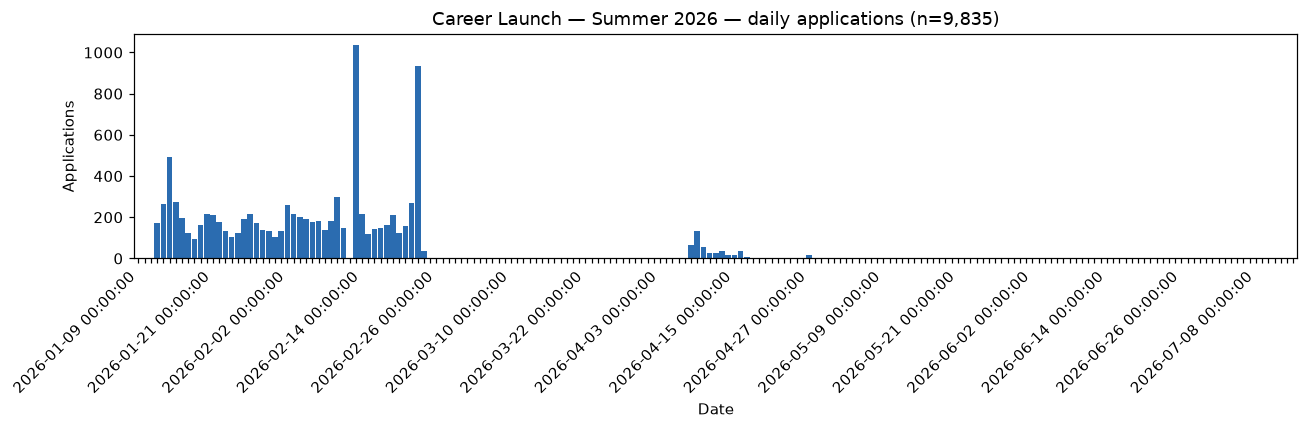

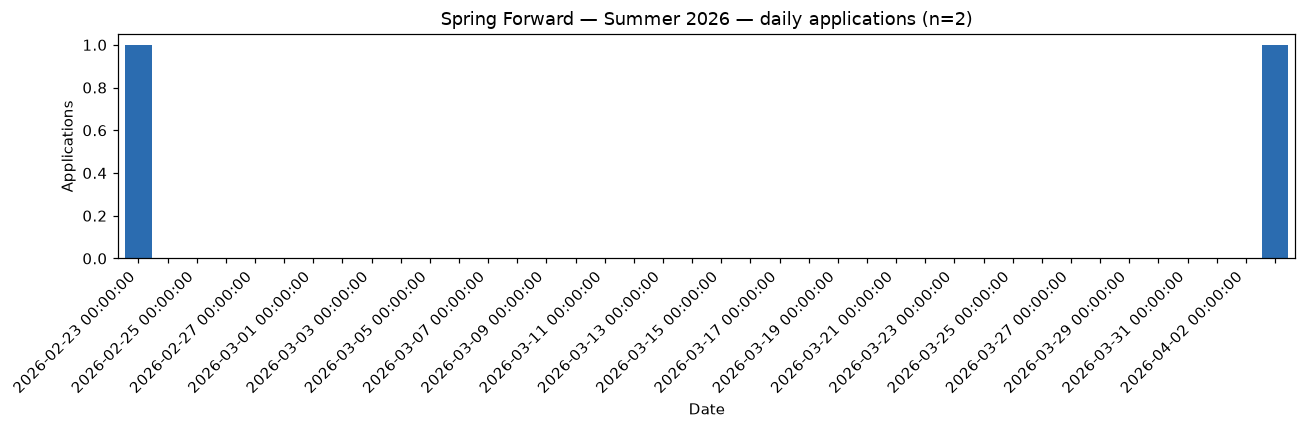

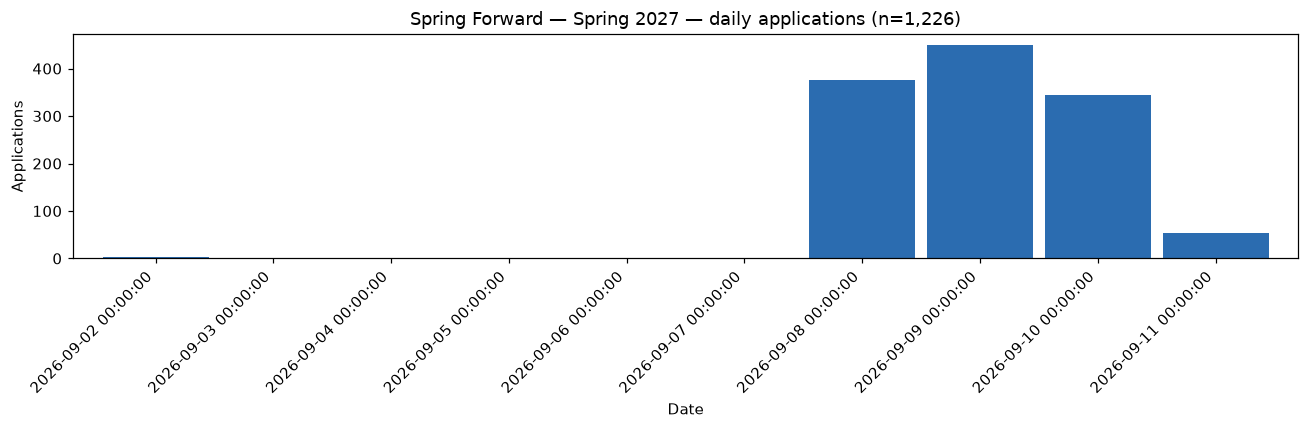

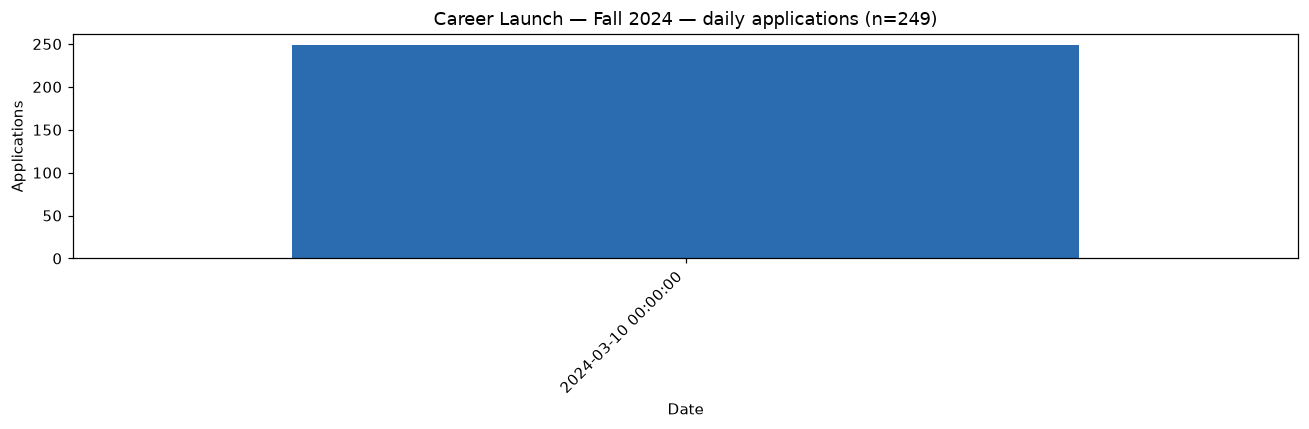

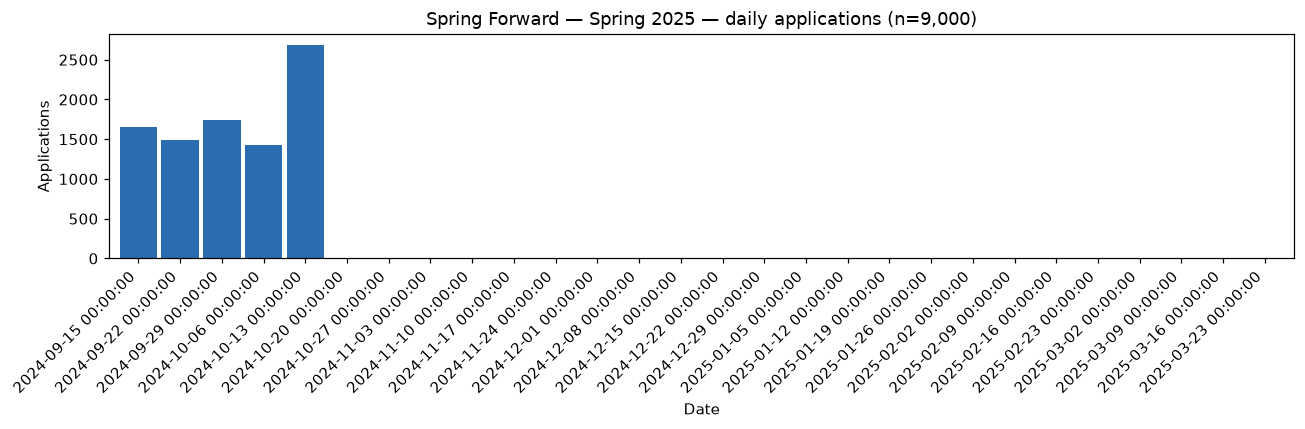

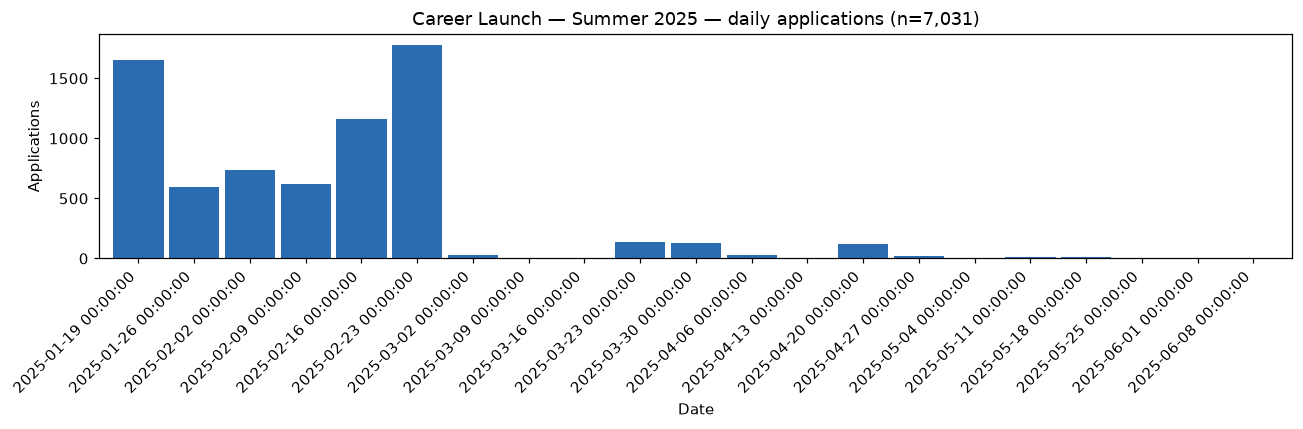

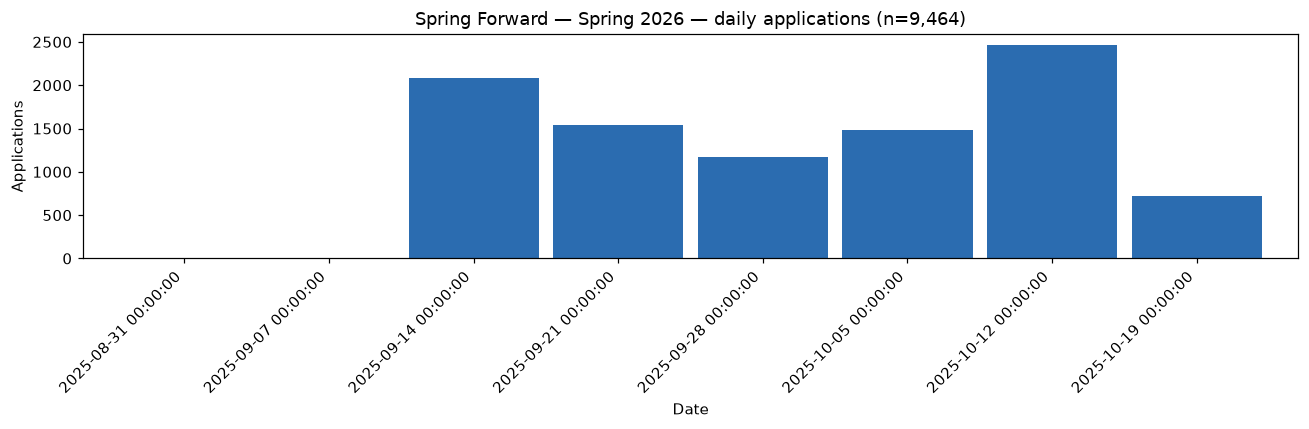

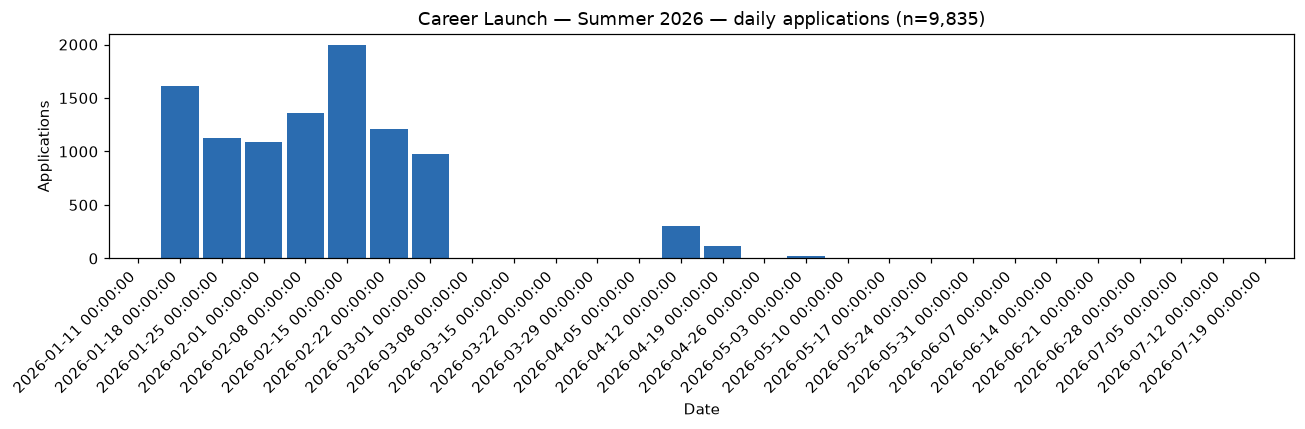

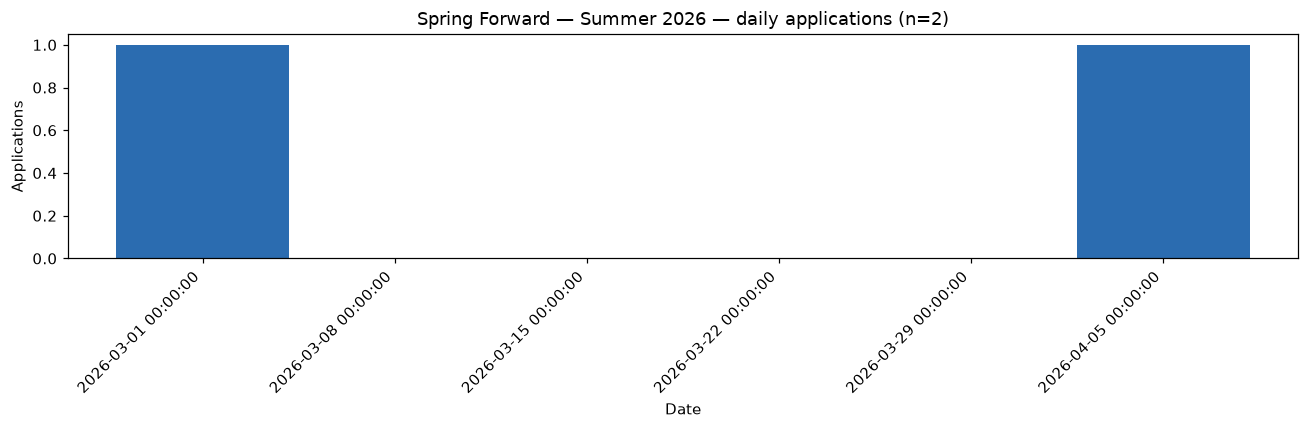

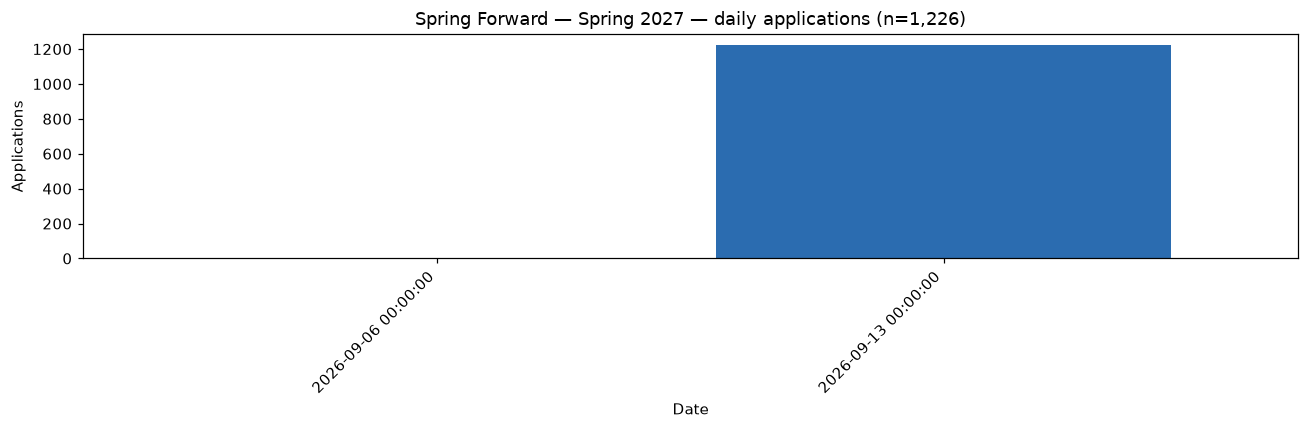

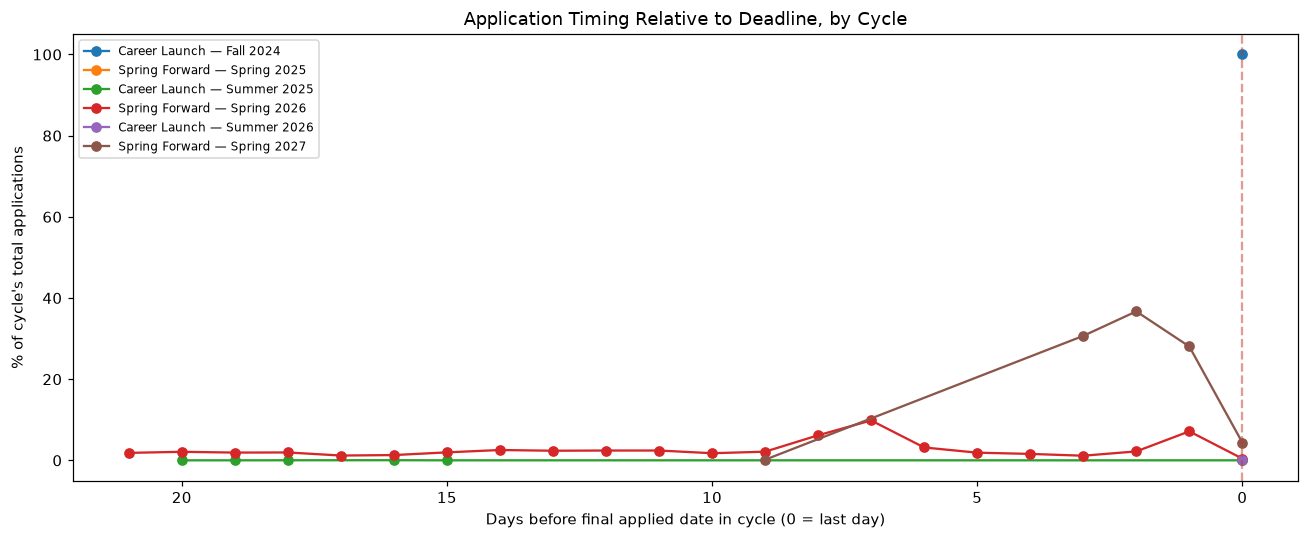

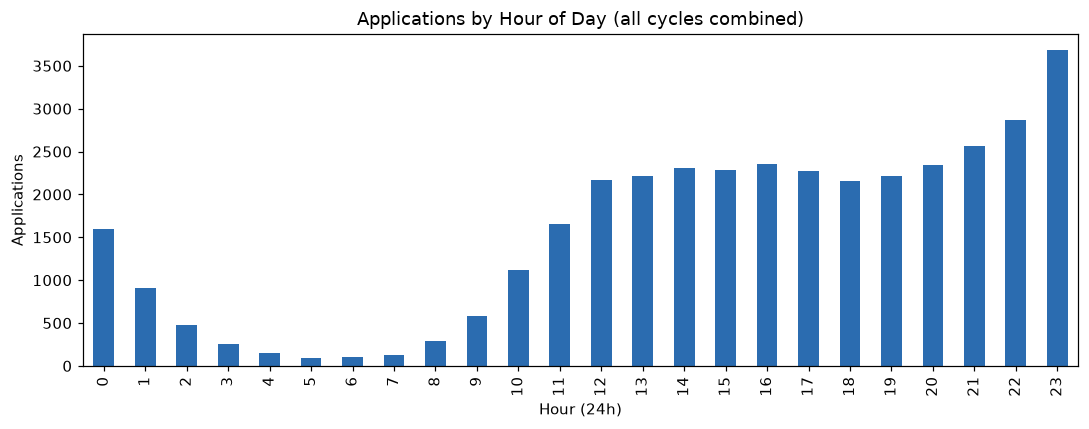

In [1]:
# %% [markdown]
# # Application Timing Analysis — Career Launch & Spring Forward
#
# Goal: understand *when* applicants apply within each program cycle, so we can
# see whether cycles are seeing "last-day spikes" (a flood of applications right
# before the deadline, which creates a grading/interviewing crunch).
#
# Run this top to bottom in Jupyter (each `# %%` is its own cell if you're using
# VS Code / Jupytext — otherwise just copy each block into its own notebook cell).
#
# Assumes `Historical_Apps.csv` is in the same folder as this script/notebook.

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

pd.set_option("display.max_columns", 50)
plt.rcParams["figure.dpi"] = 110

# Where to drop chart images so you can pull them into a deck for your boss
OUTPUT_DIR = Path("charts")
OUTPUT_DIR.mkdir(exist_ok=True)

# %% [markdown]
# ## 1. Load & clean
#
# We only need a handful of columns for this analysis. `low_memory=False`
# avoids a dtype-guessing warning on this file (it has some sparse numeric
# columns like Major Score).

# %%
df = pd.read_csv("Historical_Apps.csv", low_memory=False)

cols_needed = ["Application_ID", "Program", "Program Semester", "Application Created On"]
df = df[cols_needed].copy()

# "Application Created On" looks like: "March 6, 2024 12:13pm"
df["applied_dt"] = pd.to_datetime(
    df["Application Created On"], format="%B %d, %Y %I:%M%p", errors="coerce"
)

n_unparsed = df["applied_dt"].isna().sum()
print(f"Rows: {len(df):,} | Unparsed dates: {n_unparsed}")
if n_unparsed:
    display(df[df["applied_dt"].isna()].head())  # noqa: F821 (Jupyter provides `display`)

df["applied_date"] = df["applied_dt"].dt.date
df["applied_hour"] = df["applied_dt"].dt.hour
df["applied_dow"] = df["applied_dt"].dt.day_name()

# %% [markdown]
# ## 2. Define "cycle"
#
# A cycle = one Program + one Program Semester (e.g. "Spring Forward — Spring 2026").
# This is what actually has its own application window / deadline.

# %%
df["Cycle"] = df["Program"] + " — " + df["Program Semester"]

cycle_summary = (
    df.groupby("Cycle")["applied_dt"]
    .agg(applications="count", first_applied="min", last_applied="max")
    .assign(span_days=lambda d: (d["last_applied"] - d["first_applied"]).dt.days)
    .sort_values("first_applied")
)
cycle_summary

# %% [markdown]
# Sanity check that list against what you know about the real deadlines —
# some cycles may have a handful of stray rows (e.g. a test entry or a very
# late manual add) that make `last_applied` misleading. Filter those out
# below if you spot any.

# %% [markdown]
# ## 3. Overall histogram — every application, full history
#
# Coarse view across all cycles combined, bucketed by week. Good as a
# "here's the whole dataset" opening slide.

# %%
fig, ax = plt.subplots(figsize=(12, 4))
df.set_index("applied_dt").resample("W")["Application_ID"].count().plot(
    kind="bar", ax=ax, width=0.9
)
ax.set_title("All Applications by Week (Career Launch + Spring Forward, all cycles)")
ax.set_xlabel("Week")
ax.set_ylabel("Applications")
# thin out x labels so they're readable
for i, label in enumerate(ax.get_xticklabels()):
    label.set_visible(i % 4 == 0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "00_overall_by_week.png")
plt.show()

# %% [markdown]
# ## 4. Per-cycle histogram, day buckets
#
# This is the main event: one chart per cycle showing daily application
# volume, so you can literally see the last-day spike (or confirm one
# cycle didn't have one).

# %%
def plot_cycle_daily(cycle_name, bin_freq="D", ax=None, annotate_peak=True):
    """Plot a daily (or weekly, with bin_freq='W') histogram of applications
    for a single cycle."""
    sub = df[df["Cycle"] == cycle_name]
    counts = sub.set_index("applied_dt").resample(bin_freq)["Application_ID"].count()
    # drop leading/trailing empty bins so the chart isn't mostly blank
    counts = counts.loc[counts.gt(0).idxmax():counts.gt(0)[::-1].idxmax()]

    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(12, 4))

    counts.plot(kind="bar", ax=ax, width=0.9, color="#2b6cb0")
    ax.set_title(f"{cycle_name} — daily applications (n={len(sub):,})")
    ax.set_xlabel("Date")
    ax.set_ylabel("Applications")

    # readable x labels regardless of how many bars there are
    step = max(1, len(counts) // 15)
    for i, label in enumerate(ax.get_xticklabels()):
        label.set_visible(i % step == 0)
        label.set_rotation(45)
        label.set_ha("right")

    if annotate_peak and len(counts):
        peak_date = counts.idxmax()
        peak_val = counts.max()
        ax.annotate(
            f"peak: {peak_val}\n{peak_date.date()}",
            xy=(counts.index.get_loc(peak_date), peak_val),
            xytext=(0, 10),
            textcoords="offset points",
            ha="center",
            fontsize=9,
            fontweight="bold",
            color="#c0392b",
        )

    if standalone:
        plt.tight_layout()
        safe_name = cycle_name.replace(" ", "_").replace("—", "-")
        plt.savefig(OUTPUT_DIR / f"daily_{safe_name}.png")
        plt.show()


for cycle_name in cycle_summary.index:
    plot_cycle_daily(cycle_name, bin_freq="D")

# %% [markdown]
# ## 5. Per-cycle histogram, week buckets
#
# Same idea, coarser — useful for the longer cycles (e.g. a Career Launch
# window that runs several months) where a daily chart is too noisy to read.

# %%
for cycle_name in cycle_summary.index:
    plot_cycle_daily(cycle_name, bin_freq="W")

# %% [markdown]
# ## 6. "Days before deadline" — compare last-day spikes across cycles
#
# The most direct way to answer your boss's question: for each cycle, count
# back from its *last* applied date (day 0 = last day) and see what share of
# applications land on the final day vs. the final week vs. earlier.
#
# This lines every cycle up on the same x-axis regardless of how long the
# window was, so you can compare "how back-loaded" each cycle is directly.

# %%
def days_before_deadline(sub_df):
    deadline = sub_df["applied_dt"].max().normalize()
    return (deadline - sub_df["applied_dt"].dt.normalize()).dt.days

fig, ax = plt.subplots(figsize=(12, 5))
max_lookback = 21  # show the final 3 weeks of each cycle

for cycle_name in cycle_summary.index:
    sub = df[df["Cycle"] == cycle_name].copy()
    if len(sub) < 20:
        continue  # skip near-empty/likely-stray cycles, e.g. a 2-row cycle
    sub["days_before"] = days_before_deadline(sub)
    daily = sub[sub["days_before"] <= max_lookback]["days_before"].value_counts().sort_index()
    daily_pct = daily / len(sub) * 100  # normalize so cycles of different sizes are comparable
    ax.plot(daily_pct.index, daily_pct.values, marker="o", label=cycle_name)

ax.invert_xaxis()  # so "0 = deadline day" reads left-to-right as time passing
ax.set_xlabel("Days before final applied date in cycle (0 = last day)")
ax.set_ylabel("% of cycle's total applications")
ax.set_title("Application Timing Relative to Deadline, by Cycle")
ax.axvline(0, color="#c0392b", linestyle="--", alpha=0.5)
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "06_days_before_deadline_overlay.png")
plt.show()

# %% [markdown]
# ## 7. Quick numeric summary: how back-loaded is each cycle?
#
# For each cycle: what % of applications came in on the final day, and what %
# came in during the final 3 days / final week. This is the table version of
# the chart above — good for a slide with actual numbers on it.

# %%
rows = []
for cycle_name in cycle_summary.index:
    sub = df[df["Cycle"] == cycle_name].copy()
    if len(sub) < 20:
        continue
    sub["days_before"] = days_before_deadline(sub)
    n = len(sub)
    rows.append({
        "Cycle": cycle_name,
        "n_applications": n,
        "pct_final_day": round((sub["days_before"] == 0).sum() / n * 100, 1),
        "pct_final_3_days": round((sub["days_before"] <= 2).sum() / n * 100, 1),
        "pct_final_week": round((sub["days_before"] <= 6).sum() / n * 100, 1),
    })

backload_summary = pd.DataFrame(rows).sort_values("pct_final_day", ascending=False)
backload_summary

# %% [markdown]
# ## 8. Time-of-day pattern (bonus)
#
# If a cycle's applications spike on the last *day*, it's often worth checking
# whether they also cluster right before a specific cutoff *time* (e.g. a
# midnight or 5pm deadline). This looks at hour-of-day across all applications.

# %%
fig, ax = plt.subplots(figsize=(10, 4))
df["applied_hour"].value_counts().sort_index().plot(kind="bar", ax=ax, color="#2b6cb0")
ax.set_title("Applications by Hour of Day (all cycles combined)")
ax.set_xlabel("Hour (24h)")
ax.set_ylabel("Applications")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "08_hour_of_day.png")
plt.show()

# %% [markdown]
# ## Next steps / things worth checking once you see the charts
#
# - If `cycle_summary` shows a cycle with a `last_applied` date that looks too
#   late/early to be real (e.g. one stray row weeks after everything else),
#   filter it out before generating the deadline-relative charts — it'll
#   throw off "days before deadline" for that whole cycle.
# - Once you've confirmed which cycle had the boss-mentioned last-day flood,
#   you can rerun `plot_cycle_daily("that cycle name", bin_freq="D")` on its
#   own for a clean, single chart to drop into a deck.
# - If it'd help, we can also bucket by hour *within* the final day for that
#   specific cycle to see exactly how late applicants were cutting it.

Cycle size (cleaned): 8,999
Spike-day applicants: 1,659 (18.4%)
'Campus': dropping 1 small categories entirely: CUNY Graduate Center (n=1)

=== Eligibility Status ===
                    pct_other_days  pct_spike_day  diff_pts
Eligibility Status                                         
Eligible                      82.2           84.6       2.4
Ineligible                    17.8           15.4      -2.4

=== Desired HUB // HUB affiliation ===
                                pct_other_days  pct_spike_day  diff_pts
Desired HUB // HUB affiliation                                         
STEM and Green                            37.6           39.2       1.6
Marketing and Communications              22.1           22.5       0.4
Community and Social Services             14.6           14.0      -0.6
Healthcare                                25.7           24.3      -1.4

=== Campus ===
                                        pct_other_days  pct_spike_day  \
Campus                          

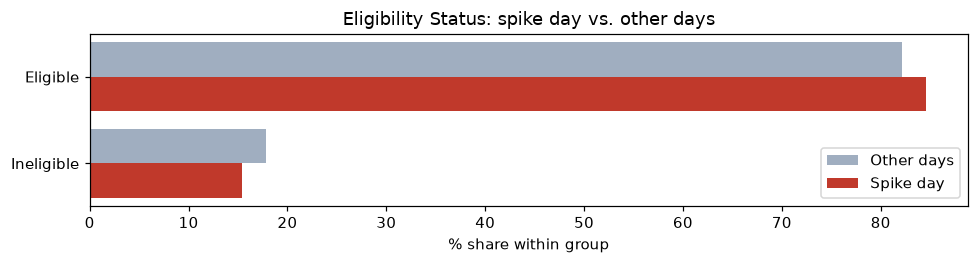

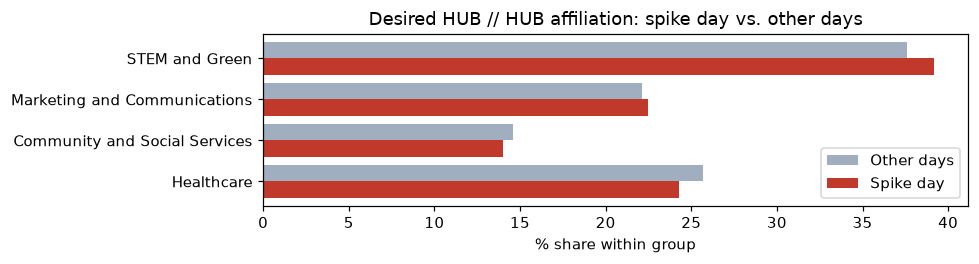

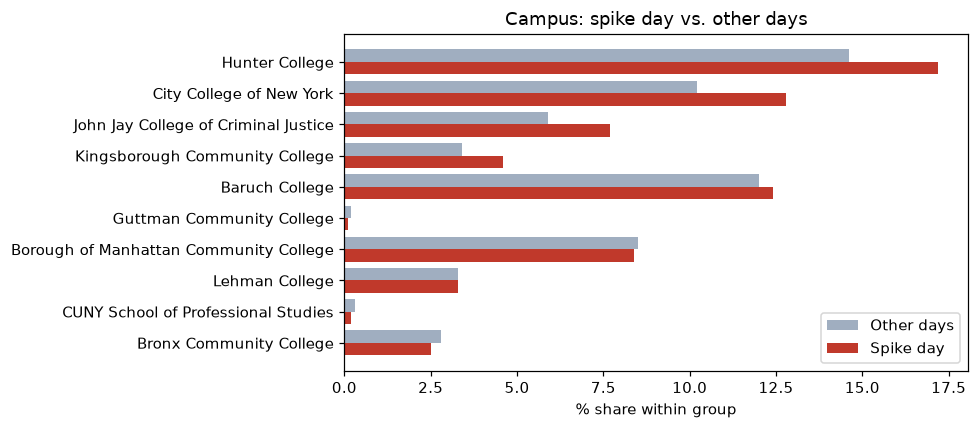

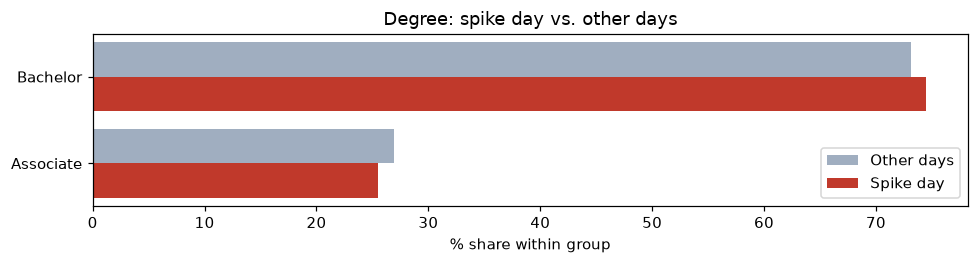

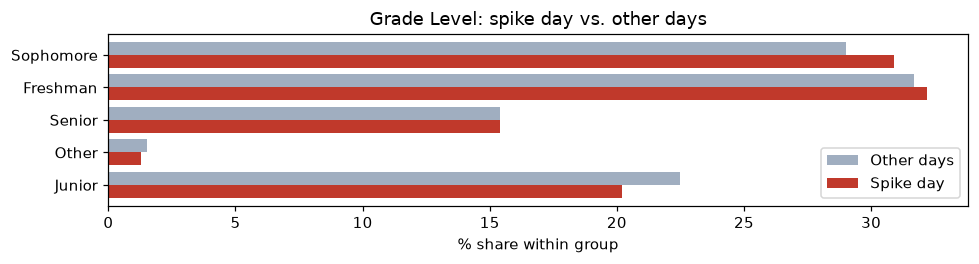

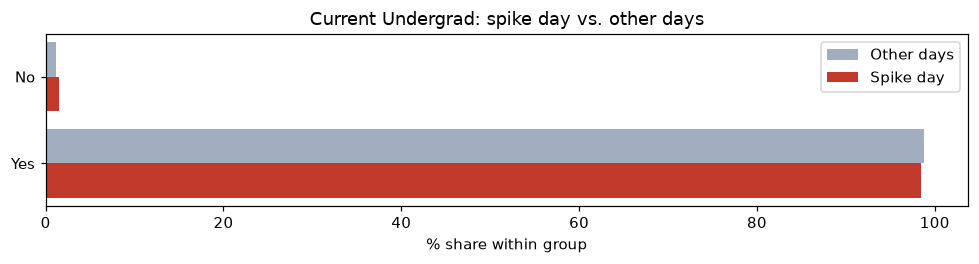

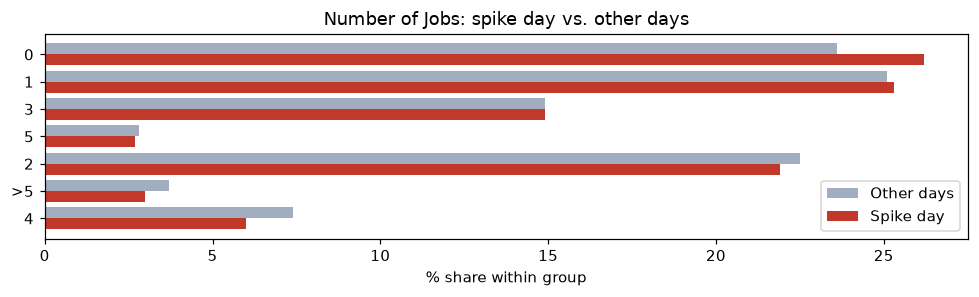

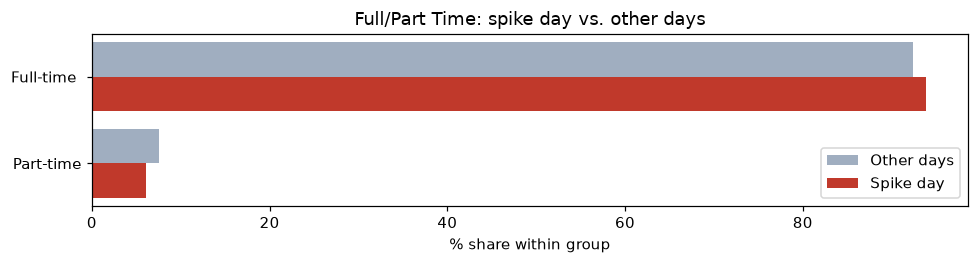

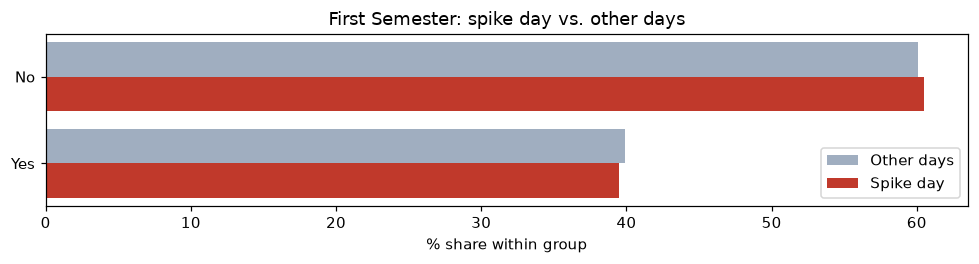

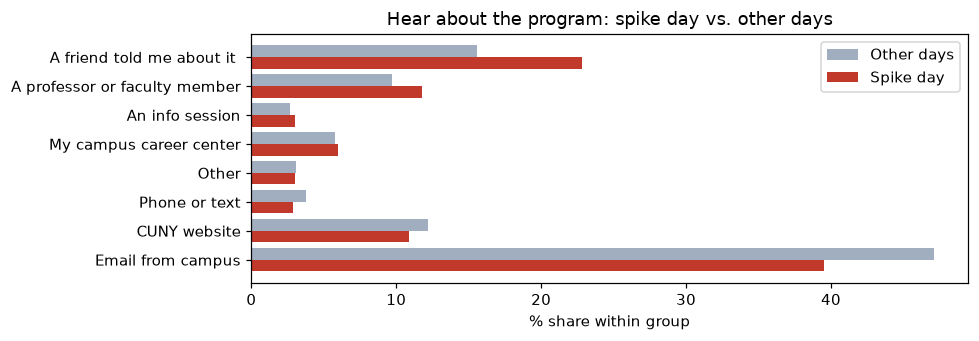

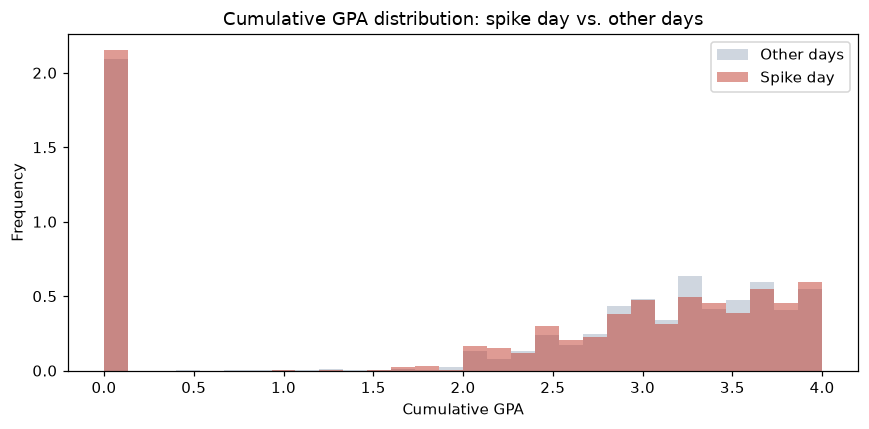

               count      mean       std  min  25%  50%  75%  max
is_spike_day                                                     
False         7340.0  2.317057  1.509944  0.0  0.0  3.0  3.5  4.0
True          1659.0  2.275130  1.518742  0.0  0.0  2.9  3.5  4.0


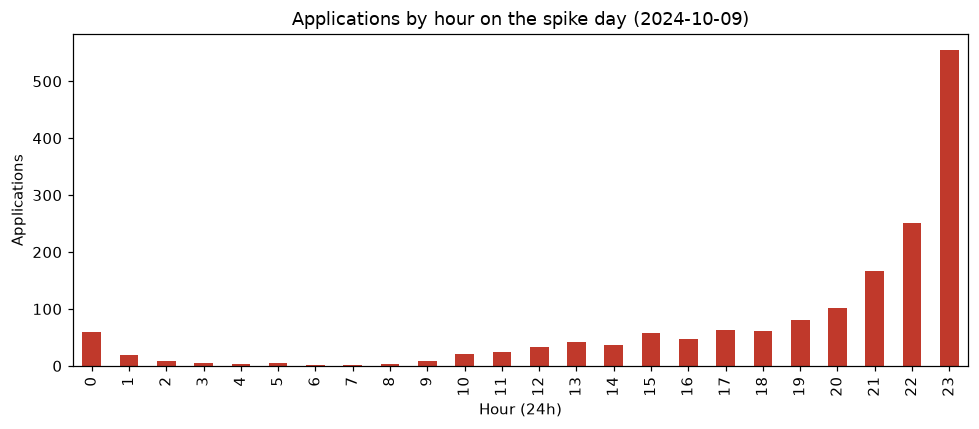

Modeling rows: 8,997 | spike-day rate: 18.4%
              precision    recall  f1-score   support

           0       0.83      0.55      0.66      1835
           1       0.21      0.52      0.29       415

    accuracy                           0.54      2250
   macro avg       0.52      0.53      0.48      2250
weighted avg       0.72      0.54      0.60      2250

ROC-AUC: 0.549


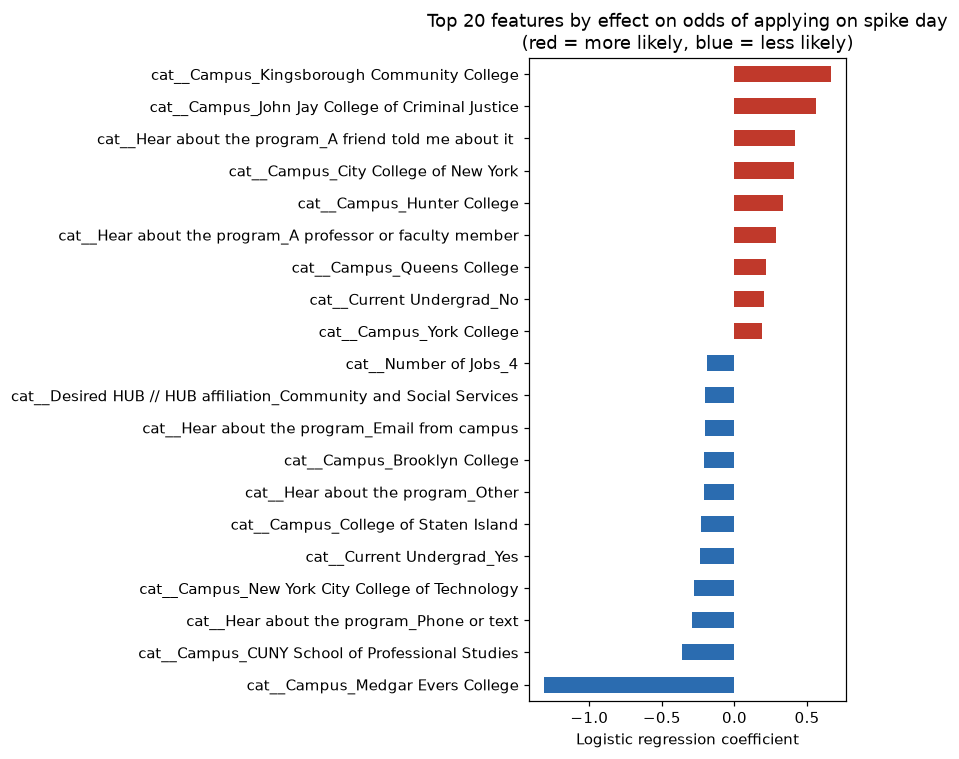

              precision    recall  f1-score   support

           0       0.83      0.77      0.80      1835
           1       0.22      0.28      0.25       415

    accuracy                           0.68      2250
   macro avg       0.52      0.53      0.52      2250
weighted avg       0.71      0.68      0.70      2250



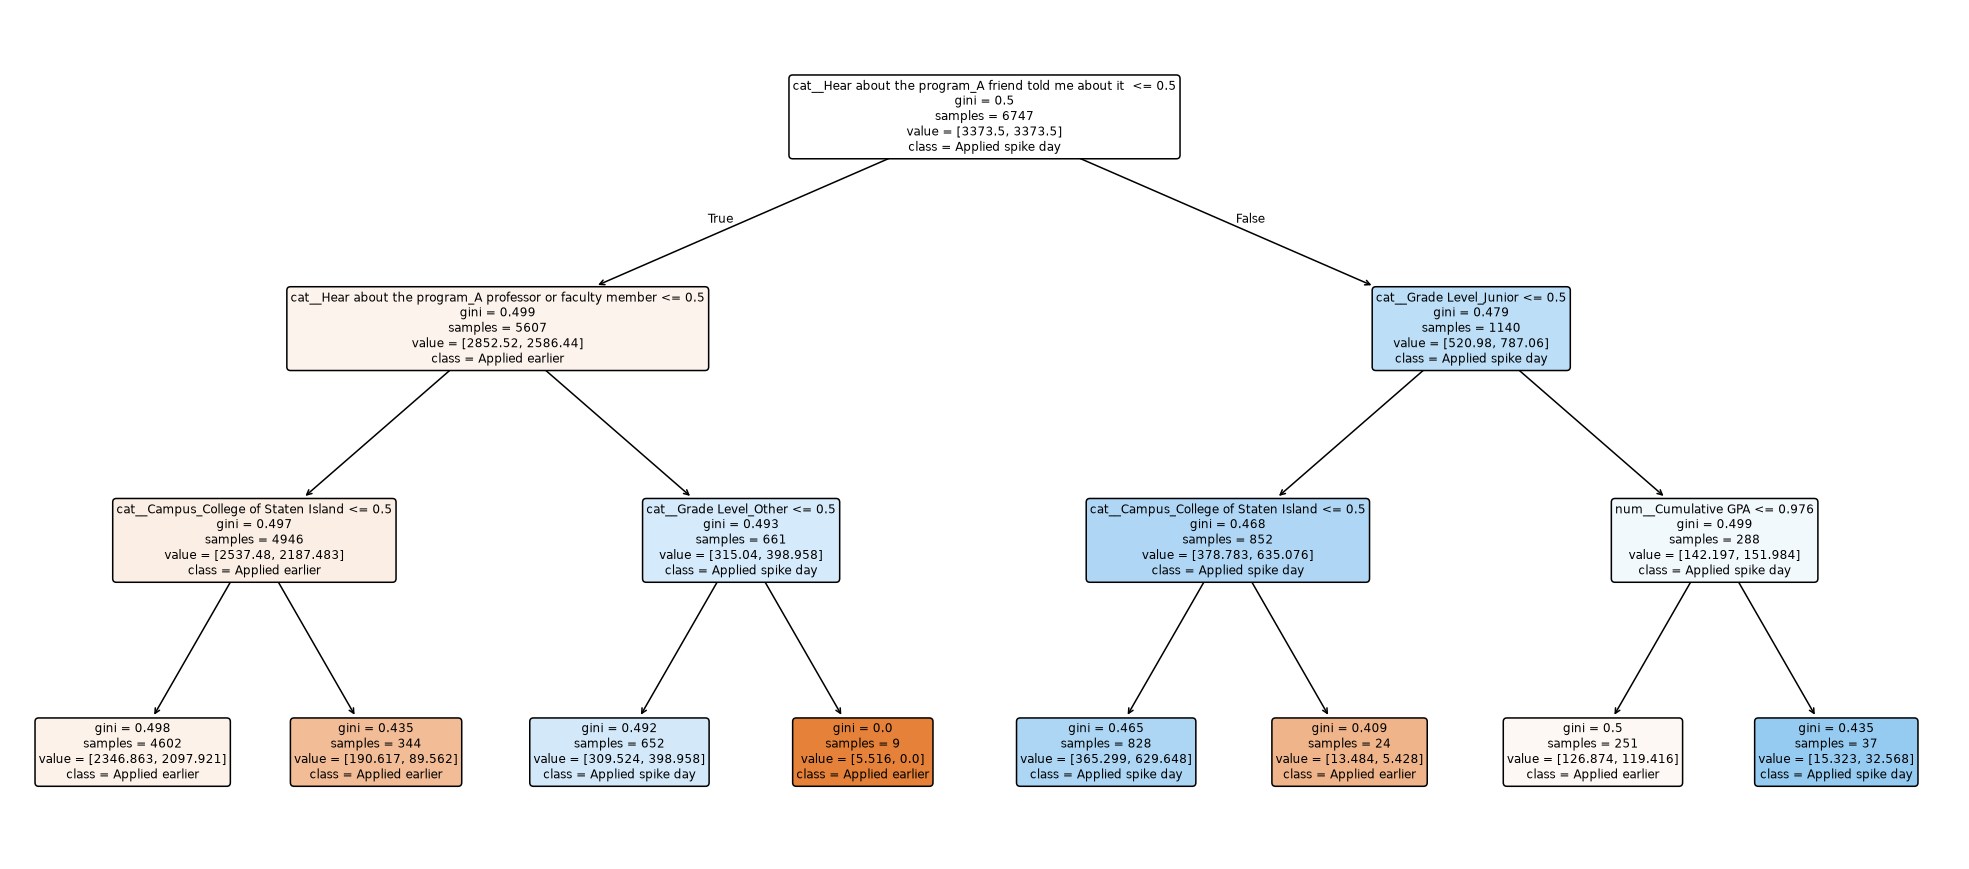

In [8]:
# %% [markdown]
# # Why the Last-Day Spike? — Spring Forward, Spring 2025 cycle
#
# From the histogram work: this cycle's window ran ~Sep 27, 2024 – Oct 10,
# 2024, and **Oct 9, 2024 alone accounted for 1,659 of the cycle's 9,000
# applications (~18%)** — a huge concentration on the second-to-last day.
#
# This script does two things:
#   1. **Exploratory stats** — do "last-day applicants" look different from
#      everyone else on the student attributes we have? (no modeling needed
#      to answer this, and it's the part most worth putting in a deck)
#   2. **A simple classifier (optional / if useful)** — predict whether a
#      student applied on the spike day, from their application attributes,
#      and see which features matter most.
#
# Assumes `Historical_Apps.csv` is in the same folder.

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
plt.rcParams["figure.dpi"] = 110

# %% [markdown]
# ## 0. Load, filter to the cycle in question, flag the spike day
#
# The spike date is set explicitly below. If you rerun this for a *different*
# cycle's spike later, this is the one line to change (plus the cycle filter).

# %%
df = pd.read_csv("Historical_Apps.csv", low_memory=False)
df["applied_dt"] = pd.to_datetime(
    df["Application Created On"], format="%B %d, %Y %I:%M%p", errors="coerce"
)

CYCLE_PROGRAM = "Spring Forward"
CYCLE_SEMESTER = "Spring 2025"
SPIKE_DATE = pd.Timestamp("2024-10-09").date()

cycle = df[(df["Program"] == CYCLE_PROGRAM) & (df["Program Semester"] == CYCLE_SEMESTER)].copy()
cycle["applied_date"] = cycle["applied_dt"].dt.date

# drop the one stray straggler row (applied ~5 months later, clearly not part
# of the real window) so it doesn't get counted as "not last-day" noise
cycle = cycle[cycle["applied_date"] <= pd.Timestamp("2024-10-15").date()]

cycle["is_spike_day"] = cycle["applied_date"] == SPIKE_DATE

print(f"Cycle size (cleaned): {len(cycle):,}")
print(f"Spike-day applicants: {cycle['is_spike_day'].sum():,} "
      f"({cycle['is_spike_day'].mean()*100:.1f}%)")

# %% [markdown]
# ### Drop tiny categories entirely
#
# Some categories (e.g. a campus with a single applicant all cycle) are too
# small to say anything meaningful about — they can only ever show up as a
# 100%/0% split, which looks like a strong signal but is just sample-size
# noise. E.g. CUNY Graduate Center has exactly 1 applicant this cycle, and
# it happens to be on the spike day, which would otherwise read as "100% of
# Graduate Center students apply last-minute."
#
# These are dropped outright (set to missing) rather than grouped into an
# "Other" bucket — a catch-all category would still show up as its own row
# in every table and bar in every chart, which is exactly what we don't want
# for genuinely tiny, uninformative groups. Rows with a missing value on a
# given column are simply excluded from that column's comparison, and from
# the model in section 5.

# %%
MIN_CATEGORY_COUNT = 15

categorical_features = [
    "Eligibility Status", "Desired HUB // HUB affiliation", "Campus", "Degree",
    "Grade Level", "Current Undergrad", "Number of Jobs", "Full/Part Time",
    "First Semester", "Hear about the program",
]

for col in categorical_features:
    counts = cycle[col].value_counts()
    rare = counts[counts < MIN_CATEGORY_COUNT].index
    if len(rare):
        print(f"'{col}': dropping {len(rare)} small categories entirely: "
              f"{', '.join(f'{v} (n={counts[v]})' for v in rare)}")
        cycle.loc[cycle[col].isin(rare), col] = np.nan

# %% [markdown]
# ## 1. Exploratory stats — spike-day vs. everyone else
#
# For each categorical student attribute, compare the mix of spike-day
# applicants to the mix of everyone else. Look for categories where the
# spike-day % is noticeably higher or lower than the baseline %.

# %%
def compare_category(col):
    """Return a table of % share within spike-day vs. % share within
    everyone else, for one categorical column."""
    tab = pd.crosstab(cycle[col], cycle["is_spike_day"], normalize="columns") * 100
    tab.columns = ["pct_other_days", "pct_spike_day"]
    tab["diff_pts"] = (tab["pct_spike_day"] - tab["pct_other_days"]).round(1)
    tab = tab.round(1).sort_values("diff_pts", ascending=False)
    return tab

for col in categorical_features:
    print(f"\n=== {col} ===")
    print(compare_category(col))

# %% [markdown]
# ## 2. Same idea, visually
#
# One bar chart per feature: spike-day % share vs. other-days % share,
# side by side. Sorted so the biggest gaps are easy to spot.

# %%
def plot_category_compare(col, top_n=10):
    tab = compare_category(col).head(top_n)
    fig, ax = plt.subplots(figsize=(9, max(2.5, 0.4 * len(tab))))
    y = np.arange(len(tab))
    ax.barh(y - 0.2, tab["pct_other_days"], height=0.4, label="Other days", color="#a0aec0")
    ax.barh(y + 0.2, tab["pct_spike_day"], height=0.4, label="Spike day", color="#c0392b")
    ax.set_yticks(y)
    ax.set_yticklabels(tab.index)
    ax.invert_yaxis()
    ax.set_xlabel("% share within group")
    ax.set_title(f"{col}: spike day vs. other days")
    ax.legend()
    plt.tight_layout()
    plt.show()

for col in categorical_features:
    plot_category_compare(col)

# %% [markdown]
# ## 3. Numeric attribute: GPA
#
# Is GPA distributed differently for spike-day applicants? (e.g. do
# last-minute applicants tend to be lower/higher GPA — maybe correlated
# with procrastination, or with eligibility uncertainty)

# %%
fig, ax = plt.subplots(figsize=(8, 4))
cycle.loc[~cycle["is_spike_day"], "Cumulative GPA"].plot(
    kind="hist", bins=30, alpha=0.5, density=True, label="Other days", ax=ax, color="#a0aec0"
)
cycle.loc[cycle["is_spike_day"], "Cumulative GPA"].plot(
    kind="hist", bins=30, alpha=0.5, density=True, label="Spike day", ax=ax, color="#c0392b"
)
ax.set_title("Cumulative GPA distribution: spike day vs. other days")
ax.set_xlabel("Cumulative GPA")
ax.legend()
plt.tight_layout()
plt.show()

print(cycle.groupby("is_spike_day")["Cumulative GPA"].describe())

# %% [markdown]
# ## 4. Hour-of-day on the spike day itself
#
# Within the spike day, when did applications actually land? This tells you
# whether it was a slow all-day build or a true last-hour crunch (useful for
# deciding whether a deadline-extension or reminder-email strategy would help).

# %%
spike_rows = cycle[cycle["is_spike_day"]].copy()
spike_rows["hour"] = spike_rows["applied_dt"].dt.hour

fig, ax = plt.subplots(figsize=(9, 4))
spike_rows["hour"].value_counts().sort_index().plot(kind="bar", ax=ax, color="#c0392b")
ax.set_title(f"Applications by hour on the spike day ({SPIKE_DATE})")
ax.set_xlabel("Hour (24h)")
ax.set_ylabel("Applications")
plt.tight_layout()
plt.show()

# %% [markdown]
# ## 5. (Optional) A simple classifier: what predicts a last-day application?
#
# Exploratory stats above should already tell a clear story. This section
# formalizes it: a logistic regression (interpretable, gives you a
# direction + magnitude per feature) and a shallow decision tree (very
# easy to explain to non-technical stakeholders — "students who are X and Y
# are more likely to wait").
#
# Deliberately **excluded** from the feature set: anything computed only
# *after* the application was reviewed (interview status, scores, drops,
# funnel tags, ineligibility reason) — those would leak the outcome and
# aren't things you'd know about a student before they apply anyway.
#
# Requires scikit-learn: `pip install scikit-learn` if you don't have it.

# %%
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, roc_auc_score

model_df = cycle.copy()

cat_features = categorical_features  # same rare-category-collapsed columns used in section 1
num_features = ["Cumulative GPA", "Priority Score"]

model_df = model_df.dropna(subset=cat_features + num_features + ["is_spike_day"])
X = model_df[cat_features + num_features]
y = model_df["is_spike_day"].astype(int)

print(f"Modeling rows: {len(X):,} | spike-day rate: {y.mean()*100:.1f}%")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

preprocess = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
    ("num", StandardScaler(), num_features),
])

# %% [markdown]
# ### 5a. Logistic regression — direction & strength of each feature

# %%
logreg = Pipeline([
    ("prep", preprocess),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced")),
])
logreg.fit(X_train, y_train)

y_pred = logreg.predict(X_test)
y_prob = logreg.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.3f}")

# Pull out the coefficients with their (readable) feature names
feature_names = logreg.named_steps["prep"].get_feature_names_out()
coefs = pd.Series(logreg.named_steps["clf"].coef_[0], index=feature_names)
top_coefs = coefs.reindex(coefs.abs().sort_values(ascending=False).index).head(20)

fig, ax = plt.subplots(figsize=(8, 7))
top_coefs.sort_values().plot(kind="barh", ax=ax, color=np.where(top_coefs.sort_values() > 0, "#c0392b", "#2b6cb0"))
ax.set_title("Top 20 features by effect on odds of applying on spike day\n(red = more likely, blue = less likely)")
ax.set_xlabel("Logistic regression coefficient")
plt.tight_layout()
plt.show()

# %% [markdown]
# ### 5b. Decision tree — easy-to-explain version
#
# Shallow on purpose (depth 3) so it's readable as a flowchart in a slide,
# not a research-grade model.

# %%
tree_clf = Pipeline([
    ("prep", preprocess),
    ("clf", DecisionTreeClassifier(max_depth=3, class_weight="balanced", random_state=42)),
])
tree_clf.fit(X_train, y_train)

y_pred_tree = tree_clf.predict(X_test)
print(classification_report(y_test, y_pred_tree))

fig, ax = plt.subplots(figsize=(18, 8))
plot_tree(
    tree_clf.named_steps["clf"],
    feature_names=tree_clf.named_steps["prep"].get_feature_names_out(),
    class_names=["Applied earlier", "Applied spike day"],
    filled=True, rounded=True, fontsize=8, ax=ax,
)
plt.tight_layout()
plt.show()

# %% [markdown]
# ## Reading the results
#
# - **ROC-AUC close to 0.5** means these student attributes barely explain
#   who waits until the last day — i.e. last-day applying is more about
#   behavior/timing (procrastination, reminder emails, deadline awareness)
#   than about who the student *is*. That's actually a useful, actionable
#   finding on its own: it points toward process fixes (earlier reminders,
#   a soft deadline, staggered close dates) rather than targeting a
#   particular student segment.
# - **ROC-AUC meaningfully above 0.5** (say, 0.65+) means some segments
#   really are more prone to waiting — check the top logistic regression
#   coefficients and the decision tree splits for which ones.
# - Either way, section 1–4 (the plain exploratory stats) are probably your
#   strongest, most defensible slides for your boss — they don't require
#   explaining a model, just showing the gap in percentages directly.

Dropping 251 rows in mismatched/unclean Program x Semester combos:
Program         Program Semester
Career Launch   Fall 2024           249
Spring Forward  Summer 2026           2
dtype: int64

Dropping 1,287 rows outside the 4 main HUBs (different deadlines):
Desired HUB // HUB affiliation
Ed Hub - Reading Fellows     555
Ed Hub - College Bridge      369
Neighborhood Mobilization    363
Name: count, dtype: int64

Clean rows retained: 35,269
Closed cycles (used for spike/backload analysis): ['Spring Forward — Spring 2025', 'Career Launch — Summer 2025', 'Spring Forward — Spring 2026', 'Career Launch — Summer 2026']
Open cycles (shown for context only, excluded from spike analysis): ['Spring Forward — Spring 2027']


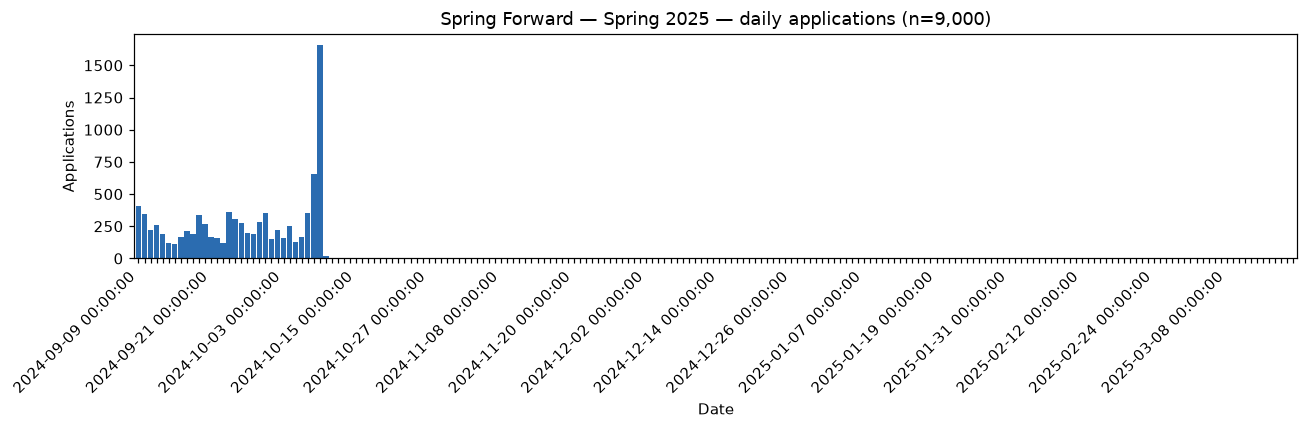

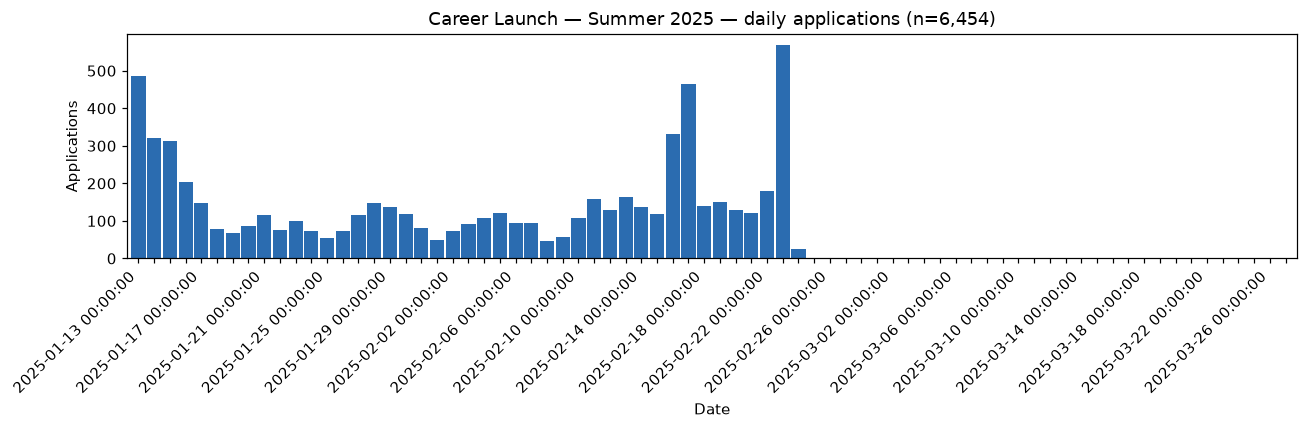

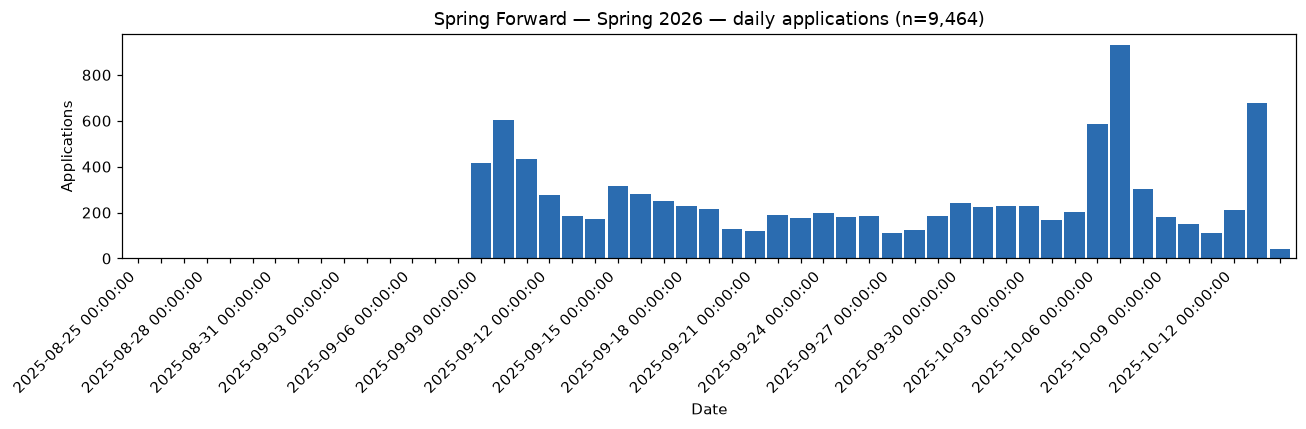

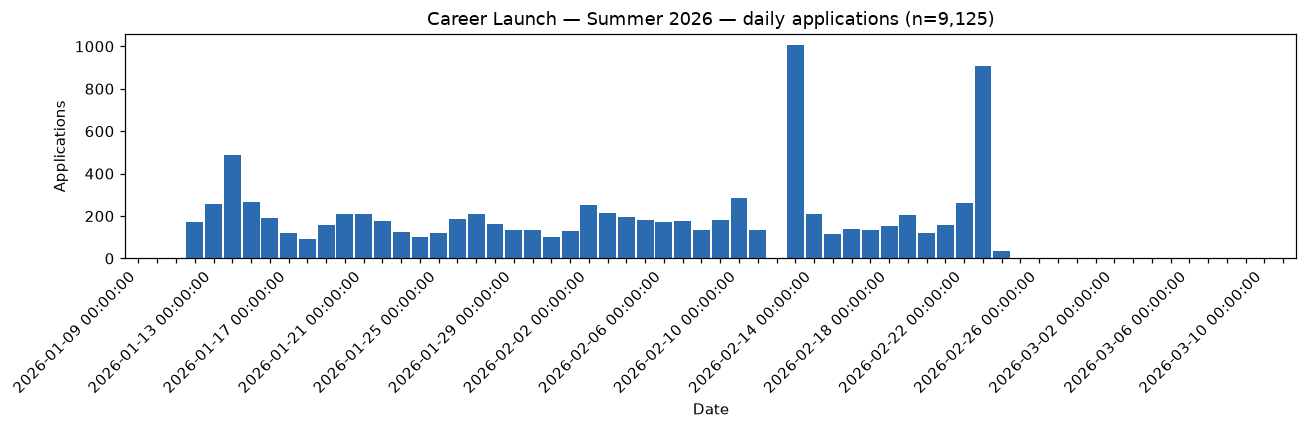

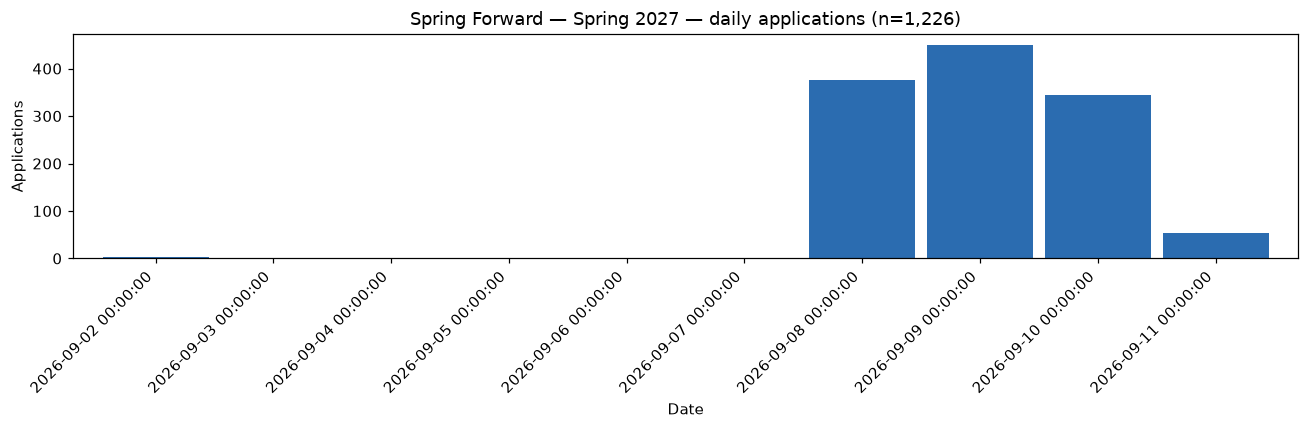


Auto-detected spike day per closed cycle:
  Spring Forward — Spring 2025: 2024-10-09
  Career Launch — Summer 2025: 2025-02-23
  Spring Forward — Spring 2026: 2025-10-07
  Career Launch — Summer 2026: 2026-02-13


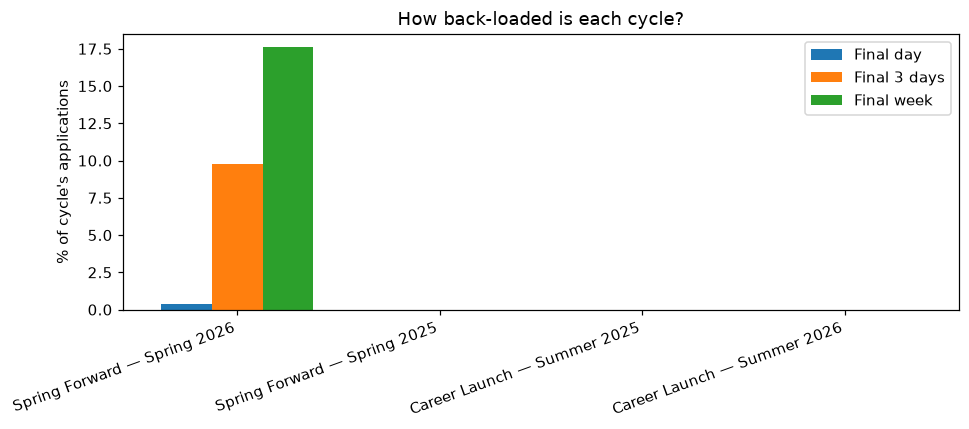


=== Eligibility Status: spike-day % minus other-days % share, by cycle (positive = over-represented on spike day) ===
                    Spring Forward — Spring 2025  Career Launch — Summer 2025  \
Eligibility Status                                                              
Eligible                                     2.4                          2.3   
Ineligible                                  -2.4                         -2.3   

                    Spring Forward — Spring 2026  Career Launch — Summer 2026  
Eligibility Status                                                             
Eligible                                     0.5                          5.5  
Ineligible                                  -0.5                         -5.5  

=== Desired HUB // HUB affiliation: spike-day % minus other-days % share, by cycle (positive = over-represented on spike day) ===
                                Spring Forward — Spring 2025  \
Desired HUB // HUB affiliation           

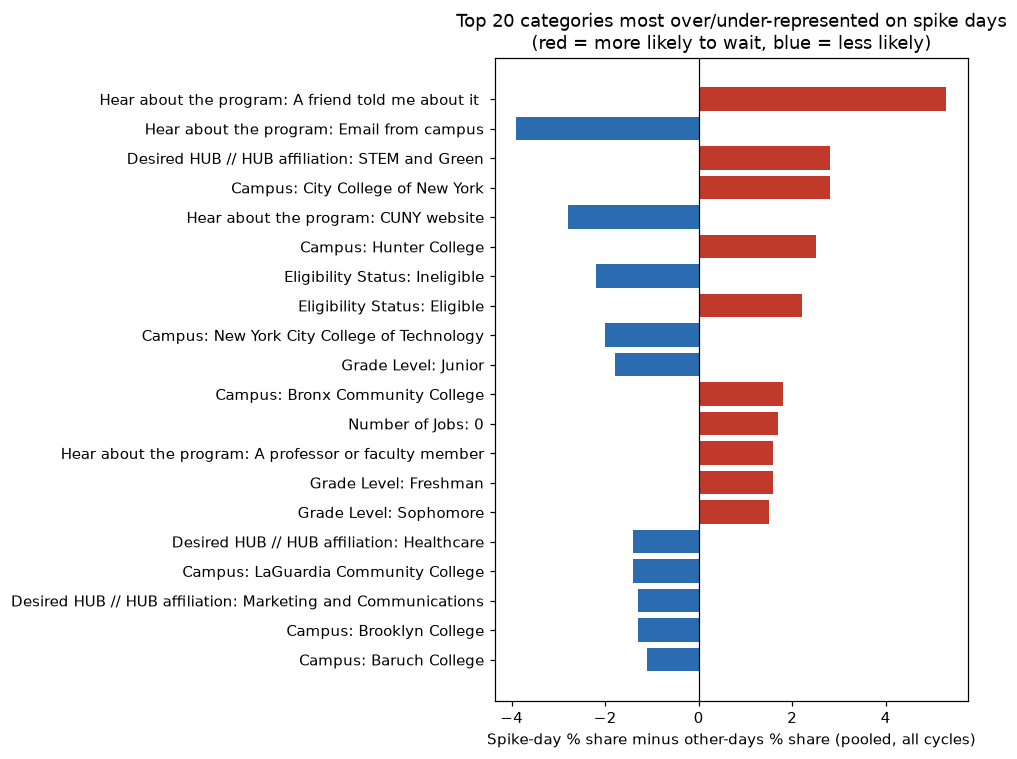

Pooled model — n=33,843, ROC-AUC=0.613

Top 20 features, controlling for Cycle:
cat__Campus_Bronx Community College                          0.80
cat__Hear about the program_Handshake                       -0.43
cat__Campus_New York City College of Technology             -0.42
cat__Campus_LaGuardia Community College                     -0.34
cat__Number of Jobs_>5                                      -0.31
cat__Hear about the program_A friend told me about it        0.28
cat__Campus_Hostos Community College                        -0.26
cat__Campus_City College of New York                         0.25
cat__Hear about the program_An info session                  0.25
cat__Campus_Brooklyn College                                -0.25
cat__Campus_York College                                    -0.24
cat__Hear about the program_CUNY website                    -0.23
cat__Campus_Medgar Evers College                             0.22
cat__Campus_Queensborough Community College                  0

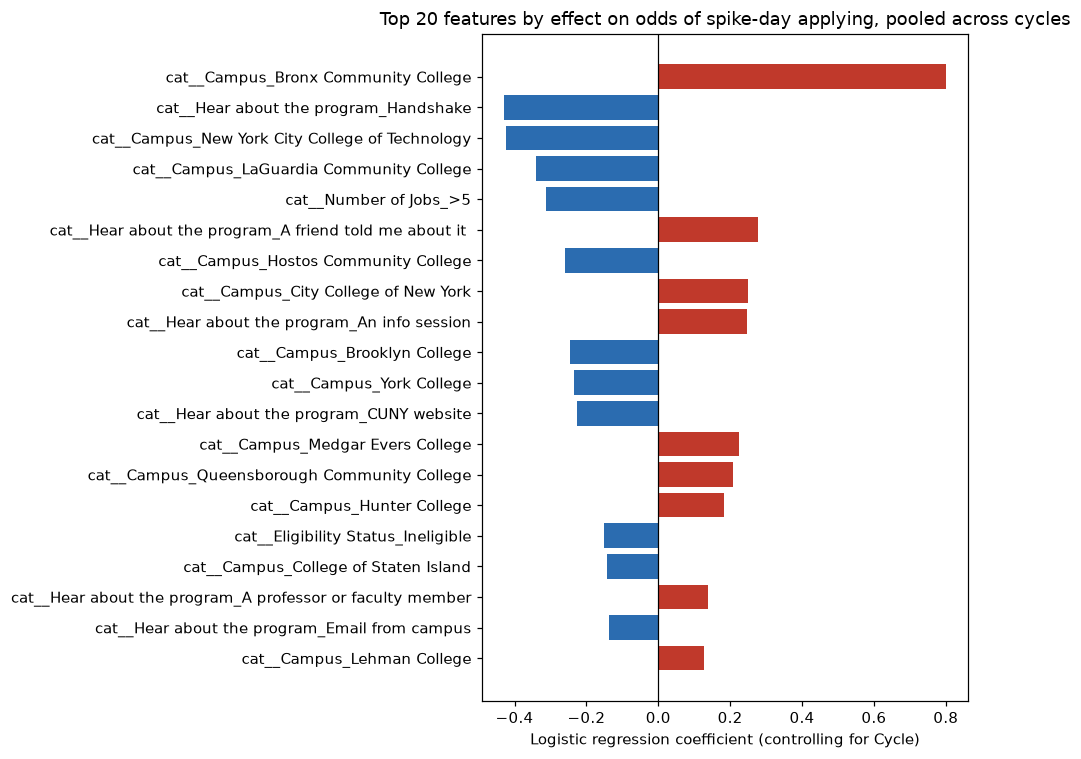

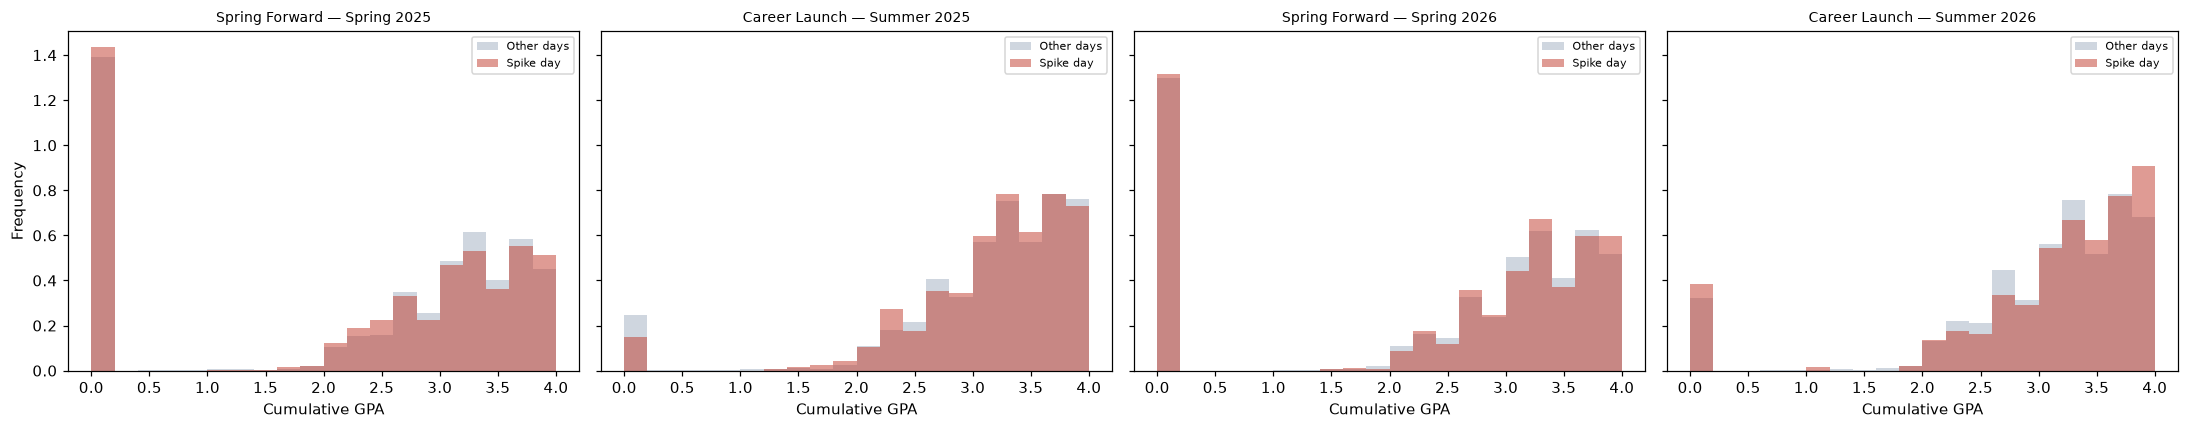

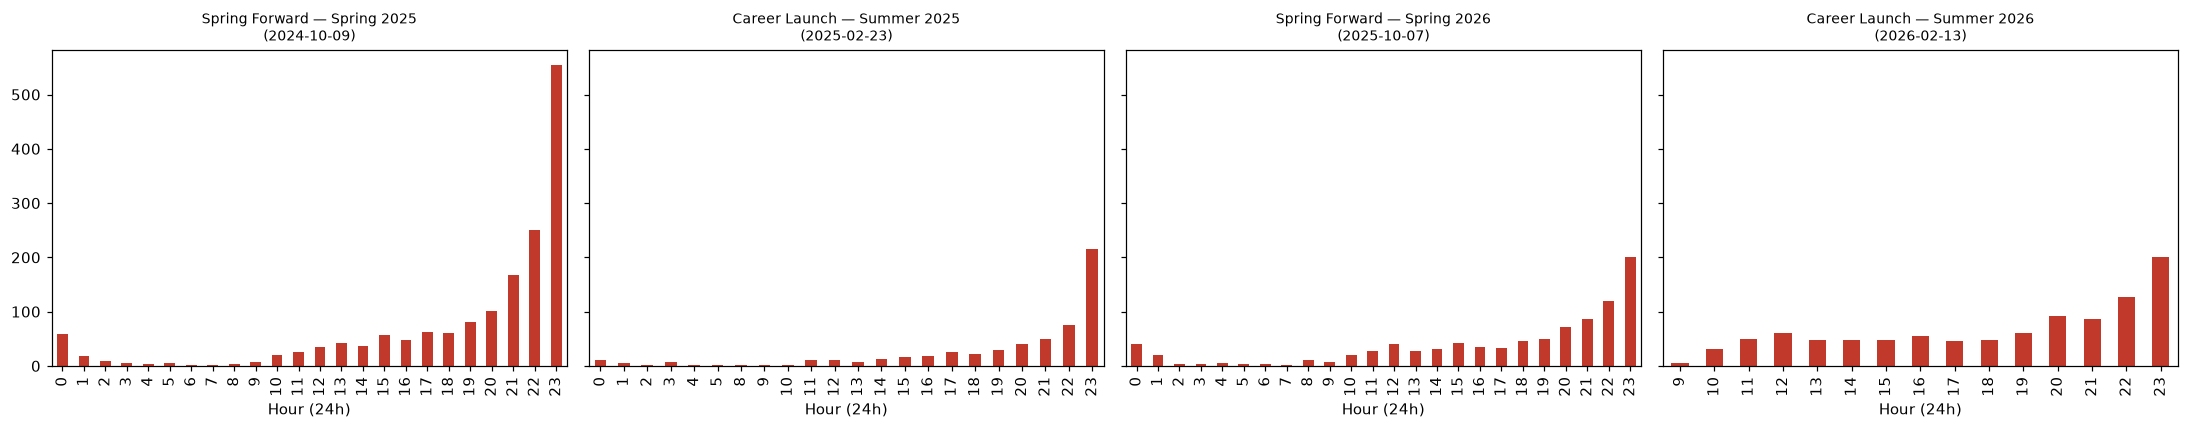

                          Cycle     n  spike_day_rate_%  ROC_AUC
0  Spring Forward — Spring 2025  8998              18.4    0.550
1   Career Launch — Summer 2025  6383               8.9    0.594
2  Spring Forward — Spring 2026  9460               9.8    0.549
3   Career Launch — Summer 2026  9002              11.0    0.600

Top 5 features — Spring Forward — Spring 2025:
cat__Campus_Medgar Evers College                         -1.32
cat__Campus_Kingsborough Community College                0.66
cat__Campus_John Jay College of Criminal Justice          0.54
cat__Hear about the program_A friend told me about it     0.41
cat__Campus_City College of New York                      0.38
dtype: float64

Top 5 features — Career Launch — Summer 2025:
cat__Campus_Hostos Community College    -2.20
cat__Campus_Guttman Community College   -1.54
cat__Campus_Queens College               1.02
cat__Grade Level_Graduate student       -0.96
cat__Campus_Hunter College               0.87
dtype: float64

Top 

In [11]:
# %% [markdown]
# # Last-Day Spike — Is It Consistent Across Cycles, and Why?
#
# We already confirmed a huge last-day spike in the Spring Forward, Spring
# 2025 cycle. This script asks two follow-up questions across **every**
# cycle we have clean data for:
#
#   1. **Is the spike-on-last-day pattern consistent across cycles**, or was
#      Spring 2025 a one-off?
#   2. **Do the same student attributes explain it in every cycle**, or does
#      "who waits until the last day" change cycle to cycle? (This tells us
#      whether a fix should target a student segment, or just be a universal
#      process change like reminder timing.)
#
# Ends with a recommendations section you can fill in once you see the
# output — the shape of the recommendation depends on what the data shows,
# so that section tells you which conclusion points to which fix.
#
# Assumes `Historical_Apps.csv` is in the same folder.

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

pd.set_option("display.max_columns", 50)
plt.rcParams["figure.dpi"] = 110

# %% [markdown]
# ## 0. Load & restrict to *valid* cycles and *main* HUBs only
#
# Two filters, both applied before anything else is computed (since spike-day
# detection itself is just "which day had the most applications" — including
# the wrong rows would shift that, not just the downstream driver analysis):
#
# 1. **Valid cycles only.** Spring Forward only runs in the Spring, Career
#    Launch only runs in the Summer. Anything else (e.g. a "Career Launch /
#    Fall 2024" row, or a couple of "Spring Forward / Summer 2026" rows) is a
#    data-entry/migration artifact — an application that landed in the wrong
#    cycle bucket — not a real cycle.
# 2. **Main 4 HUBs only** — Healthcare, Community and Social Services, STEM
#    and Green, Marketing and Communications. Ed Hub (Reading Fellows /
#    College Bridge) and Neighborhood Mobilization run on **different
#    deadlines** than the main cohort, so mixing them in would contaminate
#    the very thing we're measuring — the "last day" for the main hubs isn't
#    the same day as the Ed Hub deadline, so leaving those rows in would blur
#    or shift the detected spike day.

# %%
df = pd.read_csv("Historical_Apps.csv", low_memory=False)
df["applied_dt"] = pd.to_datetime(
    df["Application Created On"], format="%B %d, %Y %I:%M%p", errors="coerce"
)

MAIN_HUBS = [
    "Healthcare",
    "Community and Social Services",
    "STEM and Green",
    "Marketing and Communications",
]

is_valid_cycle = (
    ((df["Program"] == "Career Launch") & df["Program Semester"].str.startswith("Summer"))
    | ((df["Program"] == "Spring Forward") & df["Program Semester"].str.startswith("Spring"))
)
is_main_hub = df["Desired HUB // HUB affiliation"].isin(MAIN_HUBS)

dropped_cycle = df[~is_valid_cycle]
dropped_hub = df[is_valid_cycle & ~is_main_hub]
print(f"Dropping {len(dropped_cycle):,} rows in mismatched/unclean Program x Semester combos:")
print(dropped_cycle.groupby(["Program", "Program Semester"]).size())
print(f"\nDropping {len(dropped_hub):,} rows outside the 4 main HUBs (different deadlines):")
print(dropped_hub["Desired HUB // HUB affiliation"].value_counts(dropna=False))

df = df[is_valid_cycle & is_main_hub].copy()
df["Cycle"] = df["Program"] + " — " + df["Program Semester"]
df["applied_date"] = df["applied_dt"].dt.date

print(f"\nClean rows retained: {len(df):,}")

# %% [markdown]
# ### Flag cycles that are still open (no real "last day" yet)
#
# A cycle whose most recent application is very close to *today* is
# probably still accepting applications — its most recent date isn't a real
# deadline, just "as of when this export was pulled." Including it in the
# deadline-relative analysis would be misleading (day 0 wouldn't mean
# "deadline," just "today"). We still show it in the daily histogram for
# context, but exclude it from spike/backload comparisons.

# %%
TODAY = pd.Timestamp.today().normalize()
OPEN_CYCLE_WINDOW_DAYS = 21  # if last applied date is within this many days of today, treat as still open

cycle_summary = (
    df.groupby("Cycle")["applied_dt"]
    .agg(applications="count", first_applied="min", last_applied="max")
    .assign(
        span_days=lambda d: (d["last_applied"] - d["first_applied"]).dt.days,
        likely_still_open=lambda d: (TODAY - d["last_applied"]).dt.days <= OPEN_CYCLE_WINDOW_DAYS,
    )
    .sort_values("first_applied")
)
cycle_summary

# %%
closed_cycles = cycle_summary[~cycle_summary["likely_still_open"]].index.tolist()
open_cycles = cycle_summary[cycle_summary["likely_still_open"]].index.tolist()
print("Closed cycles (used for spike/backload analysis):", closed_cycles)
print("Open cycles (shown for context only, excluded from spike analysis):", open_cycles)

# %% [markdown]
# ## 1. Per-cycle daily histogram, with spike day auto-detected
#
# For each closed cycle, find the single day with the most applications and
# what % of the whole cycle landed on it.

# %%
def plot_cycle_daily(cycle_name, ax=None):
    sub = df[df["Cycle"] == cycle_name]
    counts = sub.set_index("applied_dt").resample("D")["Application_ID"].count()
    counts = counts.loc[counts.gt(0).idxmax():counts.gt(0)[::-1].idxmax()]

    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(12, 4))

    counts.plot(kind="bar", ax=ax, width=0.9, color="#2b6cb0")
    ax.set_title(f"{cycle_name} — daily applications (n={len(sub):,})")
    ax.set_xlabel("Date")
    ax.set_ylabel("Applications")
    step = max(1, len(counts) // 15)
    for i, label in enumerate(ax.get_xticklabels()):
        label.set_visible(i % step == 0)
        label.set_rotation(45)
        label.set_ha("right")

    if len(counts):
        peak_date, peak_val = counts.idxmax(), counts.max()
        ax.annotate(
            f"peak: {peak_val}\n{peak_date.date()}\n({peak_val/len(sub)*100:.0f}% of cycle)",
            xy=(counts.index.get_loc(peak_date), peak_val),
            xytext=(0, 10), textcoords="offset points",
            ha="center", fontsize=9, fontweight="bold", color="#c0392b",
        )
    if standalone:
        plt.tight_layout()
        plt.show()
    return counts

spike_dates = {}
for cycle_name in cycle_summary.index:
    counts = plot_cycle_daily(cycle_name)
    if cycle_name in closed_cycles:
        spike_dates[cycle_name] = counts.idxmax().date()

print("\nAuto-detected spike day per closed cycle:")
for c, d in spike_dates.items():
    print(f"  {c}: {d}")

# %% [markdown]
# ## 2. Is the backload consistent across cycles?
#
# For each closed cycle, % of applications on the final day / final 3 days /
# final week — the direct answer to "is this a Spring 2025 fluke or does it
# happen every cycle?"

# %%
def days_before_deadline(sub_df):
    deadline = sub_df["applied_dt"].max().normalize()
    return (deadline - sub_df["applied_dt"].dt.normalize()).dt.days

rows = []
for cycle_name in closed_cycles:
    sub = df[df["Cycle"] == cycle_name].copy()
    sub["days_before"] = days_before_deadline(sub)
    n = len(sub)
    rows.append({
        "Cycle": cycle_name,
        "n_applications": n,
        "pct_final_day": round((sub["days_before"] == 0).sum() / n * 100, 1),
        "pct_final_3_days": round((sub["days_before"] <= 2).sum() / n * 100, 1),
        "pct_final_week": round((sub["days_before"] <= 6).sum() / n * 100, 1),
    })

backload_summary = pd.DataFrame(rows).sort_values("pct_final_day", ascending=False)
backload_summary

# %%
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(backload_summary))
ax.bar(x - 0.25, backload_summary["pct_final_day"], width=0.25, label="Final day")
ax.bar(x, backload_summary["pct_final_3_days"], width=0.25, label="Final 3 days")
ax.bar(x + 0.25, backload_summary["pct_final_week"], width=0.25, label="Final week")
ax.set_xticks(x)
ax.set_xticklabels(backload_summary["Cycle"], rotation=20, ha="right")
ax.set_ylabel("% of cycle's applications")
ax.set_title("How back-loaded is each cycle?")
ax.legend()
plt.tight_layout()
plt.show()

# %% [markdown]
# ## 3. Set up per-cycle spike-day flag + drop tiny categories
#
# Same approach as the single-cycle version: flag each row as spike-day or
# not (within its own cycle), and drop any category with too few applicants
# in that cycle to say anything meaningful (set to missing, not lumped into
# an "Other" bucket — a tiny category shouldn't show up as its own row
# anywhere, under any label).

# %%
MIN_CATEGORY_COUNT = 15

categorical_features = [
    "Eligibility Status", "Desired HUB // HUB affiliation", "Campus", "Degree",
    "Grade Level", "Current Undergrad", "Number of Jobs", "Full/Part Time",
    "First Semester", "Hear about the program",
]
num_features = ["Cumulative GPA", "Priority Score"]

work = df[df["Cycle"].isin(closed_cycles)].copy()
work["is_spike_day"] = work.apply(
    lambda r: r["applied_date"] == spike_dates[r["Cycle"]], axis=1
)

# drop rare categories *within each cycle separately* — a category can be
# common in one cycle and rare in another
for cycle_name in closed_cycles:
    mask = work["Cycle"] == cycle_name
    for col in categorical_features:
        counts = work.loc[mask, col].value_counts()
        rare = counts[counts < MIN_CATEGORY_COUNT].index
        if len(rare):
            work.loc[mask & work[col].isin(rare), col] = np.nan

# %% [markdown]
# ## 4. Cross-cycle comparison: which attributes drive spike-day applying?
#
# For every cycle x feature x category combo, compute the same "spike-day %
# share minus other-days % share" we used before — then lay cycles side by
# side so you can see whether the *same* categories are driving it in every
# cycle, or whether it's different each time (i.e. no consistent driver,
# pointing toward a behavioral/process explanation instead).

# %%
def diff_table_for_cycle(cycle_name, col):
    sub = work[work["Cycle"] == cycle_name]
    tab = pd.crosstab(sub[col], sub["is_spike_day"], normalize="columns") * 100
    if False not in tab.columns or True not in tab.columns:
        return pd.Series(dtype=float)  # cycle has no variation in one group for this column
    return (tab[True] - tab[False]).round(1)

for col in categorical_features:
    combined = pd.DataFrame({c: diff_table_for_cycle(c, col) for c in closed_cycles})
    combined["avg_abs_diff"] = combined.abs().mean(axis=1)
    combined = combined.sort_values("avg_abs_diff", ascending=False).drop(columns="avg_abs_diff")
    print(f"\n=== {col}: spike-day % minus other-days % share, by cycle (positive = over-represented on spike day) ===")
    print(combined.round(1))

# %% [markdown]
# The table above is the key cross-cycle read: a category with a
# consistently large, same-direction number across *every* cycle column is a
# real, repeatable driver. A category that's +8 in one cycle and -6 in
# another isn't a driver at all — that's noise, and it's exactly the kind of
# thing that would mislead you if you only ever looked at one cycle.

# %% [markdown]
# ## 4b. Pooled across all cycles — one combined answer
#
# Section 4 asks "is the same driver consistent cycle to cycle?" This asks
# the more direct question: **ignoring which cycle it was, across every
# spike day we have, which student attributes are over/under-represented?**
# Every closed cycle's rows are stacked together and compared as one group
# (spike day, in whichever cycle it happened) vs. everyone else.
#
# This can surface a real pattern that's too small to stand out in any one
# cycle's smaller sample, but shows up clearly once you have more data behind
# it — at the cost of a cycle with a lot more applicants (e.g. Spring 2026)
# naturally carrying more weight in the pooled number than a smaller one.

# %%
def pooled_diff_table(col):
    tab = pd.crosstab(work[col], work["is_spike_day"], normalize="columns") * 100
    if False not in tab.columns or True not in tab.columns:
        return pd.Series(dtype=float)
    diff = (tab[True] - tab[False]).round(1)
    return diff.sort_values(key=abs, ascending=False)

pooled_results = []
for col in categorical_features:
    diff = pooled_diff_table(col)
    for category, val in diff.items():
        pooled_results.append({"feature": col, "category": category, "diff_pts": val})

pooled_df = pd.DataFrame(pooled_results).sort_values("diff_pts", key=abs, ascending=False)
print(f"Pooled n = {len(work):,} across {len(closed_cycles)} closed cycles "
      f"({work['is_spike_day'].mean()*100:.1f}% overall spike-day rate)\n")
pooled_df.head(20)

# %%
top20 = pooled_df.head(20).iloc[::-1]  # reverse so biggest is at top of the barh
fig, ax = plt.subplots(figsize=(9, 7))
labels = top20["feature"] + ": " + top20["category"].astype(str)
colors = np.where(top20["diff_pts"] > 0, "#c0392b", "#2b6cb0")
ax.barh(labels, top20["diff_pts"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Spike-day % share minus other-days % share (pooled, all cycles)")
ax.set_title("Top 20 categories most over/under-represented on spike days\n(red = more likely to wait, blue = less likely)")
plt.tight_layout()
plt.show()

# %% [markdown]
# ## 4c. Pooled classifier — one model, all cycles, with Cycle as a control
#
# A single logistic regression across all closed cycles' data, same features
# as section 7's per-cycle models, plus `Cycle` itself as a feature. Adding
# `Cycle` matters here: without it, the pooled model could confuse "which
# cycle you're in" with "which attributes you have," since cycles differ in
# their overall spike-day rate and their mix of students. Including it lets
# the other coefficients reflect the attribute's effect *within* a cycle,
# averaged across cycles — closer to the real answer to "controlling for
# which cycle it was, what predicts waiting."

# %%
pooled_cat_features = categorical_features + ["Cycle"]

pooled_model_df = work.dropna(subset=pooled_cat_features + num_features)
X_pooled = pooled_model_df[pooled_cat_features + num_features]
y_pooled = pooled_model_df["is_spike_day"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X_pooled, y_pooled, test_size=0.25, random_state=42, stratify=y_pooled
)
preprocess_pooled = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), pooled_cat_features),
    ("num", StandardScaler(), num_features),
])
pooled_pipe = Pipeline([
    ("prep", preprocess_pooled),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced")),
])
pooled_pipe.fit(X_train, y_train)
pooled_auc = roc_auc_score(y_test, pooled_pipe.predict_proba(X_test)[:, 1])
print(f"Pooled model — n={len(X_pooled):,}, ROC-AUC={pooled_auc:.3f}")

pooled_feature_names = pooled_pipe.named_steps["prep"].get_feature_names_out()
pooled_coefs = pd.Series(pooled_pipe.named_steps["clf"].coef_[0], index=pooled_feature_names)
# exclude the Cycle dummy variables themselves from the "top features" list —
# we included Cycle to control for it, not because "which cycle" is an
# actionable finding about student attributes
pooled_coefs_no_cycle = pooled_coefs[~pooled_coefs.index.str.startswith("cat__Cycle_")]
top_pooled = pooled_coefs_no_cycle.reindex(
    pooled_coefs_no_cycle.abs().sort_values(ascending=False).index
).head(20)
print("\nTop 20 features, controlling for Cycle:")
print(top_pooled.round(2))

fig, ax = plt.subplots(figsize=(9, 7))
plot_vals = top_pooled.iloc[::-1]
ax.barh(plot_vals.index, plot_vals.values, color=np.where(plot_vals.values > 0, "#c0392b", "#2b6cb0"))
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Logistic regression coefficient (controlling for Cycle)")
ax.set_title("Top 20 features by effect on odds of spike-day applying, pooled across cycles")
plt.tight_layout()
plt.show()

# %% [markdown]
# ## 5. GPA distribution: spike day vs. other days, all cycles side by side

# %%
fig, axes = plt.subplots(1, len(closed_cycles), figsize=(5 * len(closed_cycles), 4), sharey=True)
if len(closed_cycles) == 1:
    axes = [axes]
for ax, cycle_name in zip(axes, closed_cycles):
    sub = work[work["Cycle"] == cycle_name]
    sub.loc[~sub["is_spike_day"], "Cumulative GPA"].plot(
        kind="hist", bins=20, alpha=0.5, density=True, label="Other days", ax=ax, color="#a0aec0"
    )
    sub.loc[sub["is_spike_day"], "Cumulative GPA"].plot(
        kind="hist", bins=20, alpha=0.5, density=True, label="Spike day", ax=ax, color="#c0392b"
    )
    ax.set_title(cycle_name, fontsize=9)
    ax.set_xlabel("Cumulative GPA")
    ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

# %% [markdown]
# ## 6. Hour-of-day on the spike day, all cycles side by side

# %%
fig, axes = plt.subplots(1, len(closed_cycles), figsize=(5 * len(closed_cycles), 4), sharey=True)
if len(closed_cycles) == 1:
    axes = [axes]
for ax, cycle_name in zip(axes, closed_cycles):
    sub = work[(work["Cycle"] == cycle_name) & (work["is_spike_day"])].copy()
    sub["hour"] = sub["applied_dt"].dt.hour
    sub["hour"].value_counts().sort_index().plot(kind="bar", ax=ax, color="#c0392b")
    ax.set_title(f"{cycle_name}\n({spike_dates[cycle_name]})", fontsize=9)
    ax.set_xlabel("Hour (24h)")
plt.tight_layout()
plt.show()

# %% [markdown]
# ## 7. (Optional) A classifier per cycle, compared
#
# Fits a separate logistic regression per cycle (same features, same
# exclusions as before — nothing computed after the application is
# submitted). Collects each cycle's ROC-AUC and top features into one
# summary table, so "does a model even find a consistent signal" is a
# single, side-by-side read rather than five separate notebooks.
#
# (Uses the sklearn imports from the top of the script — requires
# scikit-learn: `pip install scikit-learn` if you don't have it.)

# %%
model_results = []
top_features_by_cycle = {}

for cycle_name in closed_cycles:
    sub = work[work["Cycle"] == cycle_name].dropna(subset=categorical_features + num_features)
    X = sub[categorical_features + num_features]
    y = sub["is_spike_day"].astype(int)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42, stratify=y
    )
    preprocess = ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(), num_features),
    ])
    pipe = Pipeline([
        ("prep", preprocess),
        ("clf", LogisticRegression(max_iter=1000, class_weight="balanced")),
    ])
    pipe.fit(X_train, y_train)
    auc = roc_auc_score(y_test, pipe.predict_proba(X_test)[:, 1])

    feature_names = pipe.named_steps["prep"].get_feature_names_out()
    coefs = pd.Series(pipe.named_steps["clf"].coef_[0], index=feature_names)
    top5 = coefs.reindex(coefs.abs().sort_values(ascending=False).index).head(5)
    top_features_by_cycle[cycle_name] = top5

    model_results.append({
        "Cycle": cycle_name, "n": len(sub), "spike_day_rate_%": round(y.mean() * 100, 1),
        "ROC_AUC": round(auc, 3),
    })

model_summary = pd.DataFrame(model_results)
print(model_summary)

for cycle_name, top5 in top_features_by_cycle.items():
    print(f"\nTop 5 features — {cycle_name}:")
    print(top5.round(2))

# %% [markdown]
# ## 8. How to read all of this / recommendations
#
# Fill in the blanks with what sections 2, 4/4b/4c, and 7 actually showed:
#
# **If the backload % in section 2 is high across every cycle** (not just
# Spring 2025) — the last-day rush is a structural pattern of how CUNY
# students engage with these deadlines, not a one-time event. That alone is
# worth flagging to your boss regardless of what causes it, since it means
# the grading/interview crunch is a *recurring* operational risk to plan
# staffing around, not a fluke to investigate once and move past.
#
# **If section 4's cross-cycle table and section 4b's pooled table show no
# category with a consistently large, same-direction gap, and section 7 and
# 4c's ROC-AUC are close to 0.5** — student attributes don't meaningfully
# predict who waits. That points toward **process-level fixes** rather than
# targeting a segment:
#   - A staggered/soft deadline (e.g. priority review for early applicants,
#     rather than one hard cutoff) to spread the load
#   - Reminder emails timed to when procrastination is highest — section 6's
#     hour-of-day chart tells you the actual crunch window to plan graders
#     around, even if you don't change the deadline itself
#   - Pre-allocating extra grading/interview capacity specifically for the
#     final 48-72 hours of every cycle, since section 2 suggests that's
#     predictable
#
# **If one or two categories DO show up consistently** — in section 4 across
# every cycle individually, *and* near the top of section 4b/4c's pooled
# results — that's a real, repeatable driver (e.g. a specific grade level or
# HUB reliably over-represented on spike day), worth a **targeted** reminder
# campaign to that segment earlier in the window, in addition to the process
# fixes above. A category that only shows up in the pooled view but not
# consistently per-cycle is weaker evidence — likely driven by one or two
# larger cycles rather than a true universal pattern.
#
# Either way: the open cycle (Spring Forward, Spring 2027) is still
# collecting applications as of this run — worth re-running this script once
# it closes to see if the pattern holds a third time.